# Preprocesamiento de Datos - Clustering de Usuarios

Este notebook realiza la **transformación del dataset de transacciones a dataset de usuarios** para el proyecto de clustering.

## Objetivos del preprocesamiento:

1. **Feature Engineering**: Generar variables RFM (Recency, Frequency, Monetary) y comportamiento
2. **Limpieza de outliers**: Detectar y eliminar/ajustar usuarios anómalos con Isolation Forest
3. **Escalado**: Normalizar features con RobustScaler (resistente a outliers)
4. **Encoding**: Codificar variables categóricas con One-Hot Encoding
5. **Reducción de dimensionalidad**: Aplicar PCA manteniendo ≥60% varianza explicada

## Dataset de entrada:
- **Archivo**: `data/interim/interim_ProyClustering/data_sanitized.csv`
- **Estructura**: Dataset de transacciones limpio (1 fila = 1 transacción)
- **Características**: 0 nulos, 0 duplicados, outliers capados, cancelaciones conservadas

## Dataset de salida:
- **Archivo**: `data/processed/data_clustering_pca.csv`
- **Estructura**: Dataset de usuarios (1 fila = 1 usuario/CustomerID)
- **Características**: Features escaladas, reducidas con PCA, listas para clustering

---
## 0. Imports, Configuración y Carga del Dataset Limpio

Preparamos el entorno de trabajo:
- Importamos todas las librerías necesarias para preprocesamiento y clustering
- Configuramos la estética visual global
- Definimos las rutas del proyecto
- Cargamos el dataset limpio de transacciones
- Verificamos que el dataset está correcto (dimensiones, nulos, duplicados)

In [74]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. IMPORTS Y CONFIGURACIÓN
# ══════════════════════════════════════════════════════════════════════════════

# ── Librerías básicas ─────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ── Preprocesamiento y escalado ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# ── Reducción de dimensionalidad ──────────────────────────────────────────────
from sklearn.decomposition import PCA

# ── Detección de anomalías ────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest

# ── Persistencia de modelos ───────────────────────────────────────────────────
import joblib

# ── Configuración visual global ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# ── Configuración de pandas ───────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('[OK] Librerías importadas correctamente')
print(f'\nVersiones:')
print(f'   - pandas: {pd.__version__}')
print(f'   - numpy: {np.__version__}')
print(f'   - matplotlib: {plt.matplotlib.__version__}')
print(f'   - seaborn: {sns.__version__}')

[OK] Librerías importadas correctamente

Versiones:
   - pandas: 3.0.2
   - numpy: 2.4.4
   - matplotlib: 3.10.8
   - seaborn: 0.13.2


In [75]:
# ── Rutas del proyecto ───────────────────────────────────────────────────────

# Ruta del dataset limpio (input)
RUTA_DATA_LIMPIA = '../../../data/interim/interim_ProyClustering/data_sanitized.csv'

# Rutas de salida
RUTA_PROCESSED = '../../../data/processed/'
RUTA_GRAFICOS  = '../../../graphics/gr_clustering/preprocesing/'
RUTA_MODELS    = '../../../models/'

# Crear directorios si no existen
os.makedirs(RUTA_PROCESSED, exist_ok=True)
os.makedirs(RUTA_GRAFICOS, exist_ok=True)
os.makedirs(RUTA_MODELS, exist_ok=True)

print('[OK] Rutas configuradas correctamente')
print(f'\nEstructura de directorios:')
print(f'   Input:')
print(f'   - Dataset limpio      : {RUTA_DATA_LIMPIA}')
print(f'\n   Output:')
print(f'   - Datos procesados    : {RUTA_PROCESSED}')
print(f'   - Gráficos            : {RUTA_GRAFICOS}')
print(f'   - Modelos (scalers)   : {RUTA_MODELS}')

[OK] Rutas configuradas correctamente

Estructura de directorios:
   Input:
   - Dataset limpio      : ../../../data/interim/interim_ProyClustering/data_sanitized.csv

   Output:
   - Datos procesados    : ../../../data/processed/
   - Gráficos            : ../../../graphics/gr_clustering/preprocesing/
   - Modelos (scalers)   : ../../../models/


In [76]:
# ── Carga del dataset limpio ─────────────────────────────────────────────────

print('='*80)
print('  CARGA DEL DATASET LIMPIO')
print('='*80)
print()
print(f'Cargando desde: {RUTA_DATA_LIMPIA}')
print()

# Cargar el dataset
df_transacciones = pd.read_csv(RUTA_DATA_LIMPIA)

# Convertir columnas de fecha a datetime
df_transacciones['InvoiceDate'] = pd.to_datetime(df_transacciones['InvoiceDate'])
df_transacciones['Fecha'] = pd.to_datetime(df_transacciones['Fecha'])
df_transacciones['Mes'] = df_transacciones['Mes'].astype(str)

print(f'[OK] Dataset cargado correctamente')
print()
print(f'{'─'*80}')
print(f'  DIMENSIONES DEL DATASET')
print(f'{'─'*80}')
print(f'  Filas (transacciones)     : {len(df_transacciones):>15,}')
print(f'  Columnas                  : {len(df_transacciones.columns):>15}')
print(f'  Tamaño en memoria         : {df_transacciones.memory_usage(deep=True).sum() / 1024**2:>15,.2f} MB')
print(f'{'─'*80}')
print()
print(f'  COLUMNAS DISPONIBLES ({len(df_transacciones.columns)}):')
for i, col in enumerate(df_transacciones.columns, 1):
    dtype = str(df_transacciones[col].dtype)
    print(f'    {i:>2}. {col:<20} ({dtype})')
print()
print('='*80)

  CARGA DEL DATASET LIMPIO

Cargando desde: ../../../data/interim/interim_ProyClustering/data_sanitized.csv

[OK] Dataset cargado correctamente

────────────────────────────────────────────────────────────────────────────────
  DIMENSIONES DEL DATASET
────────────────────────────────────────────────────────────────────────────────
  Filas (transacciones)     :         399,651
  Columnas                  :              13
  Tamaño en memoria         :          155.56 MB
────────────────────────────────────────────────────────────────────────────────

  COLUMNAS DISPONIBLES (13):
     1. InvoiceNo            (str)
     2. StockCode            (str)
     3. Description          (str)
     4. Quantity             (int64)
     5. InvoiceDate          (datetime64[us])
     6. UnitPrice            (float64)
     7. CustomerID           (float64)
     8. Country              (str)
     9. Fecha                (datetime64[us])
    10. Mes                  (str)
    11. DiaSemana            (str

In [77]:
# ── Verificación de calidad del dataset ──────────────────────────────────────

print('='*80)
print('  VERIFICACIÓN DE CALIDAD DEL DATASET')
print('='*80)
print()

# ── Verificación 1: Valores nulos ─────────────────────────────────────────────
nulos_total = df_transacciones.isnull().sum().sum()
nulos_por_columna = df_transacciones.isnull().sum()

print(f'  ✓ VERIFICACIÓN 1: VALORES NULOS')
print(f'  {'─'*78}')
print(f'     Total valores nulos       : {nulos_total:>10,}')
if nulos_total > 0:
    print(f'     [!] ATENCIÓN: Hay valores nulos en el dataset')
    print(f'\n     Columnas con nulos:')
    for col, count in nulos_por_columna[nulos_por_columna > 0].items():
        pct = (count / len(df_transacciones) * 100)
        print(f'       - {col:<20} : {count:>8,} ({pct:>6.2f}%)')
else:
    print(f'     [OK] No hay valores nulos')
print()

# ── Verificación 2: Duplicados ────────────────────────────────────────────────
duplicados = df_transacciones.duplicated().sum()

print(f'  ✓ VERIFICACIÓN 2: DUPLICADOS EXACTOS')
print(f'  {'─'*78}')
print(f'     Filas duplicadas          : {duplicados:>10,}')
if duplicados > 0:
    print(f'     [!] ATENCIÓN: Hay {duplicados:,} filas duplicadas')
else:
    print(f'     [OK] No hay duplicados')
print()

# ── Verificación 3: CustomerID únicos ─────────────────────────────────────────
num_usuarios = df_transacciones['CustomerID'].nunique()
customerid_nulos = df_transacciones['CustomerID'].isnull().sum()

print(f'  ✓ VERIFICACIÓN 3: CUSTOMERID (crítico para clustering)')
print(f'  {'─'*78}')
print(f'     Usuarios únicos (CustomerID) : {num_usuarios:>10,}')
print(f'     CustomerID nulos             : {customerid_nulos:>10,}')
if customerid_nulos > 0:
    print(f'     [ERROR] Hay CustomerID nulos → no se puede hacer clustering')
else:
    print(f'     [OK] Todos los registros tienen CustomerID')
print()

# ── Verificación 4: Distribución básica ───────────────────────────────────────
num_productos = df_transacciones['StockCode'].nunique()
num_facturas = df_transacciones['InvoiceNo'].nunique()
num_paises = df_transacciones['Country'].nunique()

print(f'  ✓ VERIFICACIÓN 4: ENTIDADES ÚNICAS')
print(f'  {'─'*78}')
print(f'     Usuarios (CustomerID)     : {num_usuarios:>10,}')
print(f'     Productos (StockCode)     : {num_productos:>10,}')
print(f'     Facturas (InvoiceNo)      : {num_facturas:>10,}')
print(f'     Países                    : {num_paises:>10,}')
print()

# ── Verificación 5: Rango temporal ────────────────────────────────────────────
fecha_min = df_transacciones['InvoiceDate'].min()
fecha_max = df_transacciones['InvoiceDate'].max()
dias_totales = (fecha_max - fecha_min).days

print(f'  ✓ VERIFICACIÓN 5: COBERTURA TEMPORAL')
print(f'  {'─'*78}')
print(f'     Fecha inicio              : {fecha_min.strftime("%Y-%m-%d")}')
print(f'     Fecha fin                 : {fecha_max.strftime("%Y-%m-%d")}')
print(f'     Duración                  : {dias_totales} días')
print()

# ── Resumen de validación ─────────────────────────────────────────────────────
print(f'{'='*80}')
errores = []
if nulos_total > 0:
    errores.append('Valores nulos detectados')
if duplicados > 0:
    errores.append('Duplicados detectados')
if customerid_nulos > 0:
    errores.append('CustomerID nulos (CRÍTICO)')

if len(errores) == 0:
    print(f'  [OK] DATASET VALIDADO CORRECTAMENTE')
    print(f'  {'─'*78}')
    print(f'     El dataset está limpio y listo para preprocesamiento')
    print(f'     Próximo paso: Generar features de usuario (RFM + comportamiento)')
else:
    print(f'  [ERROR] ERRORES DETECTADOS EN EL DATASET')
    print(f'  {'─'*78}')
    for error in errores:
        print(f'     • {error}')
    print(f'\n     [!] Revisar el notebook de limpieza antes de continuar')

print(f'{'='*80}')

  VERIFICACIÓN DE CALIDAD DEL DATASET

  ✓ VERIFICACIÓN 1: VALORES NULOS
  ──────────────────────────────────────────────────────────────────────────────
     Total valores nulos       :          0
     [OK] No hay valores nulos

  ✓ VERIFICACIÓN 2: DUPLICADOS EXACTOS
  ──────────────────────────────────────────────────────────────────────────────
     Filas duplicadas          :          0
     [OK] No hay duplicados

  ✓ VERIFICACIÓN 3: CUSTOMERID (crítico para clustering)
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios únicos (CustomerID) :      4,362
     CustomerID nulos             :          0
     [OK] Todos los registros tienen CustomerID

  ✓ VERIFICACIÓN 4: ENTIDADES ÚNICAS
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios (CustomerID)     :      4,362
     Productos (StockCode)     :      3,676
     Facturas (InvoiceNo)      :     21,785
     Países                    :         37

 

In [78]:
# ── Vista previa del dataset ─────────────────────────────────────────────────

print('\nVISTA PREVIA DEL DATASET (primeras 10 filas):')
print('='*80)
display(df_transacciones.head(10))

print('\nESTADÍSTICAS DESCRIPTIVAS (columnas numéricas):')
print('='*80)
display(df_transacciones.describe())

print('\nINFORMACIÓN DEL DATAFRAME:')
print('='*80)
df_transacciones.info()


VISTA PREVIA DEL DATASET (primeras 10 filas):



VISTA PREVIA DEL DATASET (primeras 10 filas):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Fecha,Mes,DiaSemana,EsCancelacion,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,54.08



VISTA PREVIA DEL DATASET (primeras 10 filas):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Fecha,Mes,DiaSemana,EsCancelacion,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,54.08


...


VISTA PREVIA DEL DATASET (primeras 10 filas):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Fecha,Mes,DiaSemana,EsCancelacion,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,54.08



ESTADÍSTICAS DESCRIPTIVAS (columnas numéricas):


,Quantity,InvoiceDate,UnitPrice,CustomerID,Fecha,TotalPrice
count,399651.00,399651,399651.00,399651.00,399651,399651.00
mean,10.63,2011-07-10 12:36:01.626669,2.80,15288.78,2011-07-09 23:21:41.266354,18.53
min,-120.00,2010-12-01 08:26:00,0.03,12346.00,2010-12-01 00:00:00,-1314.00
25%,2.00,2011-04-06 15:07:00,1.25,13959.00,2011-04-06 00:00:00,4.25
50%,5.00,2011-07-29 15:51:00,1.95,15152.00,2011-07-29 00:00:00,11.56
75%,12.00,2011-10-20 12:03:00,3.75,16791.00,2011-10-20 00:00:00,19.50
max,120.00,2011-12-09 12:50:00,12.75,18287.00,2011-12-09 00:00:00,1530.00
std,18.43,NaN,2.65,1710.78,NaN,38.08



INFORMACIÓN DEL DATAFRAME:
<class 'pandas.DataFrame'>
RangeIndex: 399651 entries, 0 to 399650
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      399651 non-null  str           
 1   StockCode      399651 non-null  str           
 2   Description    399651 non-null  str           
 3   Quantity       399651 non-null  int64         
 4   InvoiceDate    399651 non-null  datetime64[us]
 5   UnitPrice      399651 non-null  float64       
 6   CustomerID     399651 non-null  float64       
 7   Country        399651 non-null  str           
 8   Fecha          399651 non-null  datetime64[us]
 9   Mes            399651 non-null  str           
 10  DiaSemana      399651 non-null  str           
 11  EsCancelacion  399651 non-null  bool          
 12  TotalPrice     399651 non-null  float64       
dtypes: bool(1), datetime64[us](2), float64(3), int64(1), str(6)
memory usage: 37.0 MB



## SIGUIENTE PASO: PASO 4 - GENERACIÓN DE FEATURES

**Objetivo**: Transformar dataset de transacciones → dataset de usuarios

En el siguiente paso crearemos:
1. **Variables RFM** (Recency, Frequency, Monetary)
2. **Variables de comportamiento** (ticket promedio, diversidad productos, gasto mensual)
3. **Variables de cancelación** (tasa devolución, ratio devuelto)
4. **Variables temporales** (día preferido, fin de semana)
5. **Variable geográfica** (país)

**Resultado esperado**: DataFrame con ~4,400 filas (1 fila por usuario) y 10-15 features

## PASO 4.1: Variables RFM (Recency, Frequency, Monetary)

**RFM** es el core del análisis de clustering en e-commerce:
- **R** (Recency): ¿Cuándo fue la última compra?
- **F** (Frequency): ¿Con qué frecuencia compra?
- **M** (Monetary): ¿Cuánto gasta en total?

---

### 4.1.A — RECENCY (Recencia)

**Definición**: Días transcurridos desde la última compra del usuario

**Interpretación**:
- Recency **bajo** (ej. 5 días) → Cliente activo, compró recientemente
- Recency **alto** (ej. 200 días) → Cliente inactivo, lleva mucho sin comprar

**Cálculo**:
```
Recency = fecha_referencia - max(InvoiceDate por usuario)
```

**Fecha de referencia**: Última fecha del dataset + 1 día  
(Simula que estamos analizando el día después del último registro)

In [79]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.A: CÁLCULO DE RECENCY (RECENCIA)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.A: RECENCY (Recencia)')
print('='*80)
print()

# ── 1. Determinar la fecha de referencia ─────────────────────────────────────
fecha_ultima_transaccion = df_transacciones['InvoiceDate'].max()
fecha_referencia = fecha_ultima_transaccion + pd.Timedelta(days=1)

print(f'FECHAS DE REFERENCIA:')
print(f'  {'─'*78}')
print(f'     Última transacción del dataset : {fecha_ultima_transaccion.strftime("%Y-%m-%d")}')
print(f'     Fecha de referencia (+ 1 día)  : {fecha_referencia.strftime("%Y-%m-%d")}')
print()

# ── 2. Calcular la última compra por usuario ─────────────────────────────
print(f'Calculando última compra por usuario...')
ultima_compra_por_usuario = df_transacciones.groupby('CustomerID')['InvoiceDate'].max()

print(f'   [OK] Calculado para {len(ultima_compra_por_usuario):,} usuarios')
print()

# ── 3. Calcular Recency (días desde la última compra) ────────────────────────
print(f'Calculando Recency (días desde última compra)...')
recency_por_usuario = (fecha_referencia - ultima_compra_por_usuario).dt.days

print(f'   [OK] Recency calculado para {len(recency_por_usuario):,} usuarios')
print()

# ── 4. Crear DataFrame con Recency ───────────────────────────────────────────
df_rfm = pd.DataFrame({
    'CustomerID': recency_por_usuario.index,
    'Recency': recency_por_usuario.values
})

print(f'[OK] DataFrame RFM creado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 5. Estadísticas descriptivas de Recency ──────────────────────────────
print(f'ESTADÍSTICAS DE RECENCY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : {df_rfm["Recency"].min():>8} días  (usuario compró recientemente)')
print(f'     Máximo         : {df_rfm["Recency"].max():>8} días  (usuario inactivo hace tiempo)')
print(f'     Media          : {df_rfm["Recency"].mean():>8.2f} días')
print(f'     Mediana        : {df_rfm["Recency"].median():>8.0f} días')
print(f'     Desv. estándar : {df_rfm["Recency"].std():>8.2f} días')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : {df_rfm["Recency"].quantile(0.25):>8.0f} días')
print(f'     P50 (Mediana)  : {df_rfm["Recency"].quantile(0.50):>8.0f} días')
print(f'     P75 (Q3)       : {df_rfm["Recency"].quantile(0.75):>8.0f} días')
print(f'     P90            : {df_rfm["Recency"].quantile(0.90):>8.0f} días')
print(f'     P95            : {df_rfm["Recency"].quantile(0.95):>8.0f} días')
print(f'     P99            : {df_rfm["Recency"].quantile(0.99):>8.0f} días')

print()
print('='*80)

  PASO 4.1.A: RECENCY (Recencia)

FECHAS DE REFERENCIA:
  ──────────────────────────────────────────────────────────────────────────────
     Última transacción del dataset : 2011-12-09
     Fecha de referencia (+ 1 día)  : 2011-12-10

Calculando última compra por usuario...
   [OK] Calculado para 4,362 usuarios

Calculando Recency (días desde última compra)...
   [OK] Recency calculado para 4,362 usuarios

[OK] DataFrame RFM creado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 2 columnas
     Columnas    : ['CustomerID', 'Recency']

ESTADÍSTICAS DE RECENCY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         :        1 días  (usuario compró recientemente)
     Máximo         :      374 días  (usuario inactivo hace tiempo)
     Media          :    92.17 días
     Mediana        :       50 días
     Desv. estándar :   100.97 días

  Percentiles:
     P25 (Q1)       :  

In [80]:
# ── Vista previa del DataFrame RFM (con Recency) ─────────────────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM (primeras 20 filas):')
print('='*80)
print()

# Mostrar ordenado por Recency (los más recientes primero)
print('TOP 10: Usuarios más ACTIVOS (Recency más bajo - compraron recientemente):')
display(df_rfm.nsmallest(10, 'Recency'))

print()
print('[!] TOP 10: Usuarios más INACTIVOS (Recency más alto - llevan sin comprar):')
display(df_rfm.nlargest(10, 'Recency'))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10).sort_values('Recency'))


VISTA PREVIA DEL DATAFRAME RFM (primeras 20 filas):

TOP 10: Usuarios más ACTIVOS (Recency más bajo - compraron recientemente):



VISTA PREVIA DEL DATAFRAME RFM (primeras 20 filas):

TOP 10: Usuarios más ACTIVOS (Recency más bajo - compraron recientemente):


,CustomerID,Recency
61,12423.00,1
71,12433.00,1
105,12476.00,1
137,12518.00,1
144,12526.00,1
259,12662.00,1
273,12680.00,1
299,12713.00,1
328,12748.00,1
475,12955.00,1



[!] TOP 10: Usuarios más INACTIVOS (Recency más alto - llevan sin comprar):


,CustomerID,Recency
357,12791.00,374
1042,13747.00,374
1760,14729.00,374
3122,16583.00,374
4086,17908.00,374
4130,17968.00,374
4202,18074.00,374
404,12855.00,373
550,13065.00,373
582,13108.00,373



Muestra aleatoria de 10 usuarios:


,CustomerID,Recency
922,13576.00,10
3480,17068.00,12
1660,14591.00,15
1090,13814.00,56
425,12884.00,88
1630,14548.00,151
1814,14803.00,162
3028,16448.00,198
3590,17230.00,264
2496,15723.00,365



VISUALIZACIÓN: Distribución de Recency

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.A_distribucion_recency.png



VISUALIZACIÓN: Distribución de Recency

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.A_distribucion_recency.png


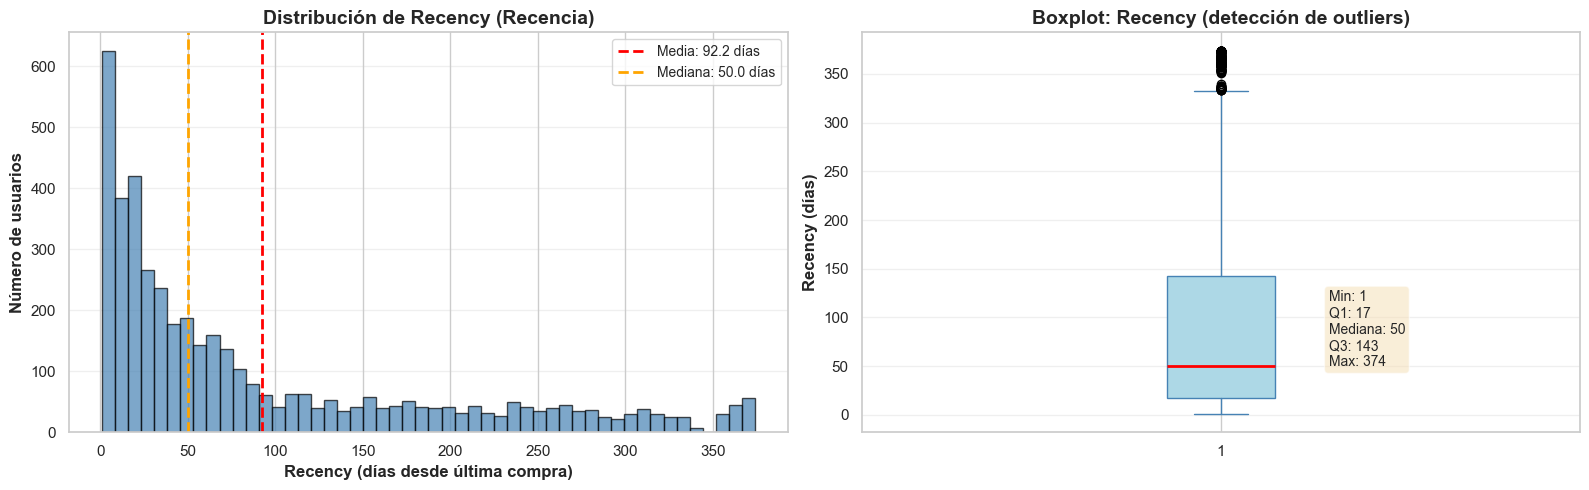

In [81]:
# ── Visualización de la distribución de Recency ──────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Recency')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma ─────────────────────────────────────────────
axes[0].hist(df_rfm['Recency'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Recency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_rfm["Recency"].mean():.1f} días')
axes[0].axvline(df_rfm['Recency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df_rfm["Recency"].median():.1f} días')
axes[0].set_xlabel('Recency (días desde última compra)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Recency (Recencia)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Recency'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Recency (días)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Recency (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir estadísticas al boxplot
stats_text = f'Min: {df_rfm["Recency"].min():.0f}\nQ1: {df_rfm["Recency"].quantile(0.25):.0f}\nMediana: {df_rfm["Recency"].median():.0f}\nQ3: {df_rfm["Recency"].quantile(0.75):.0f}\nMax: {df_rfm["Recency"].max():.0f}'
axes[1].text(1.15, df_rfm['Recency'].median(), stats_text, fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Guardar gráfico
ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.A_distribucion_recency.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)

---

### 4.1.B — FREQUENCY (Frecuencia)

**Definición**: Número total de transacciones (compras únicas) del usuario

**Interpretación**:
- Frequency **bajo** (ej. 1-2 compras) → Cliente ocasional, una sola compra
- Frequency **alto** (ej. 50+ compras) → Cliente frecuente/fiel, compra regularmente

**Cálculo**:
```
Frequency = count(InvoiceNo único por usuario)
```

**Nota importante**: Contamos facturas únicas (`InvoiceNo`), no líneas de transacción. Una factura puede tener múltiples productos.

**Filtro de cancelaciones**: Solo contamos facturas de compra (no cancelaciones que empiezan con 'C')

In [82]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.B: CÁLCULO DE FREQUENCY (FRECUENCIA)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.B: FREQUENCY (Frecuencia)')
print('='*80)
print()

# ── 1. Filtrar solo transacciones de compra (sin cancelaciones) ──────────────
print(f'Filtrando transacciones...')
print(f'  {'─'*78}')

# Total de transacciones
total_transacciones = len(df_transacciones)
print(f'     Total transacciones (todas)       : {total_transacciones:>10,}')

# Filtrar cancelaciones (InvoiceNo que NO empiezan con 'C')
df_compras = df_transacciones[~df_transacciones['InvoiceNo'].astype(str).str.startswith('C')]
transacciones_compra = len(df_compras)
print(f'     Transacciones de COMPRA           : {transacciones_compra:>10,}')

# Calcular cancelaciones
transacciones_cancelacion = total_transacciones - transacciones_compra
pct_cancelacion = (transacciones_cancelacion / total_transacciones * 100)
print(f'     Transacciones de CANCELACIÓN      : {transacciones_cancelacion:>10,} ({pct_cancelacion:.2f}%)')
print()

# ── 2. Calcular el número de facturas únicas por usuario ─────────────────────
print(f'Calculando número de facturas únicas por usuario...')

# Contar facturas únicas (InvoiceNo) por CustomerID
frequency_por_usuario = df_compras.groupby('CustomerID')['InvoiceNo'].nunique()

print(f'   [OK] Frequency calculado para {len(frequency_por_usuario):,} usuarios')
print()

# ── 3. Agregar Frequency al DataFrame RFM ─────────────────────────────
print(f'Agregando Frequency al DataFrame RFM...')

# Merge con df_rfm
df_rfm = df_rfm.merge(
    frequency_por_usuario.rename('Frequency'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)

# Rellenar con 0 si hay usuarios sin compras (solo cancelaciones)
df_rfm['Frequency'] = df_rfm['Frequency'].fillna(0).astype(int)

print(f'   [OK] Frequency agregado correctamente')
print()

print(f'[OK] DataFrame RFM actualizado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas descriptivas de Frequency ─────────────────────────────────
print(f'ESTADÍSTICAS DE FREQUENCY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : {df_rfm["Frequency"].min():>8} compras  (cliente de 1 sola compra)')
print(f'     Máximo         : {df_rfm["Frequency"].max():>8} compras  (cliente super frecuente)')
print(f'     Media          : {df_rfm["Frequency"].mean():>8.2f} compras')
print(f'     Mediana        : {df_rfm["Frequency"].median():>8.0f} compras')
print(f'     Desv. estándar : {df_rfm["Frequency"].std():>8.2f} compras')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : {df_rfm["Frequency"].quantile(0.25):>8.0f} compras')
print(f'     P50 (Mediana)  : {df_rfm["Frequency"].quantile(0.50):>8.0f} compras')
print(f'     P75 (Q3)       : {df_rfm["Frequency"].quantile(0.75):>8.0f} compras')
print(f'     P90            : {df_rfm["Frequency"].quantile(0.90):>8.0f} compras')
print(f'     P95            : {df_rfm["Frequency"].quantile(0.95):>8.0f} compras')
print(f'     P99            : {df_rfm["Frequency"].quantile(0.99):>8.0f} compras')
print()

# ── 5. Distribución de usuarios por rango de Frequency ───────────────────────
print(f'DISTRIBUCIÓN DE USUARIOS POR RANGO DE FREQUENCY:')
print(f'  {'─'*78}')

# Definir rangos
bins = [0, 1, 5, 10, 20, 50, 100, float('inf')]
labels = ['1 compra', '2-5 compras', '6-10 compras', '11-20 compras', '21-50 compras', '51-100 compras', '100+ compras']
df_rfm['Frequency_Range'] = pd.cut(df_rfm['Frequency'], bins=bins, labels=labels, right=True)

# Calcular distribución
distribucion = df_rfm['Frequency_Range'].value_counts().sort_index()

for rango, count in distribucion.items():
    pct = (count / len(df_rfm) * 100)
    print(f'     {str(rango):<20} : {count:>6,} usuarios ({pct:>6.2f}%)')

# Eliminar columna temporal
df_rfm.drop('Frequency_Range', axis=1, inplace=True)

print()
print('='*80)

  PASO 4.1.B: FREQUENCY (Frecuencia)

Filtrando transacciones...
  ──────────────────────────────────────────────────────────────────────────────
     Total transacciones (todas)       :    399,651
     Transacciones de COMPRA           :    391,145
     Transacciones de CANCELACIÓN      :      8,506 (2.13%)

Calculando número de facturas únicas por usuario...
   [OK] Frequency calculado para 4,334 usuarios

Agregando Frequency al DataFrame RFM...
   [OK] Frequency agregado correctamente

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 3 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency']

ESTADÍSTICAS DE FREQUENCY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         :        0 compras  (cliente de 1 sola compra)
     Máximo         :      206 compras  (cliente super frecuente)
     Media          :     4.22 compras
     Med

In [83]:
# ── Vista previa del DataFrame RFM (con Recency + Frequency) ─────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM (con Recency + Frequency):')
print('='*80)
print()

# Mostrar ordenado por Frequency (los más frecuentes primero)
print('TOP 10: Usuarios más FRECUENTES (Frequency más alto):')
display(df_rfm.nsmallest(10, 'Recency').nlargest(10, 'Frequency'))

print()
print('[!] TOP 10: Usuarios OCASIONALES (Frequency más bajo - 1 sola compra):')
display(df_rfm.nsmallest(10, 'Frequency').head(10))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10).sort_values('Frequency', ascending=False))


VISTA PREVIA DEL DATAFRAME RFM (con Recency + Frequency):

TOP 10: Usuarios más FRECUENTES (Frequency más alto):



VISTA PREVIA DEL DATAFRAME RFM (con Recency + Frequency):

TOP 10: Usuarios más FRECUENTES (Frequency más alto):


,CustomerID,Recency,Frequency
328,12748.00,1,206
105,12476.00,1,11
259,12662.00,1,11
475,12955.00,1,11
61,12423.00,1,8
71,12433.00,1,7
137,12518.00,1,5
273,12680.00,1,4
144,12526.00,1,3
299,12713.00,1,1



[!] TOP 10: Usuarios OCASIONALES (Frequency más bajo - 1 sola compra):


,CustomerID,Recency,Frequency
210,12605.00,365,0
262,12666.00,359,0
413,12870.00,366,0
465,12943.00,301,0
1000,13693.00,325,0
1102,13829.00,359,0
1196,13958.00,372,0
1314,14119.00,354,0
1380,14213.00,372,0
1684,14627.00,312,0



Muestra aleatoria de 10 usuarios:


,CustomerID,Recency,Frequency
2142,15249.00,32,13
4008,17799.00,22,10
579,13104.00,3,6
1774,14748.00,29,5
838,13467.00,11,2
1800,14784.00,26,2
1534,14427.00,50,2
2033,15109.00,241,1
2477,15699.00,18,1
2899,16272.00,117,1



VISUALIZACIÓN: Distribución de Frequency

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.B_distribucion_frequency.png



VISUALIZACIÓN: Distribución de Frequency

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.B_distribucion_frequency.png


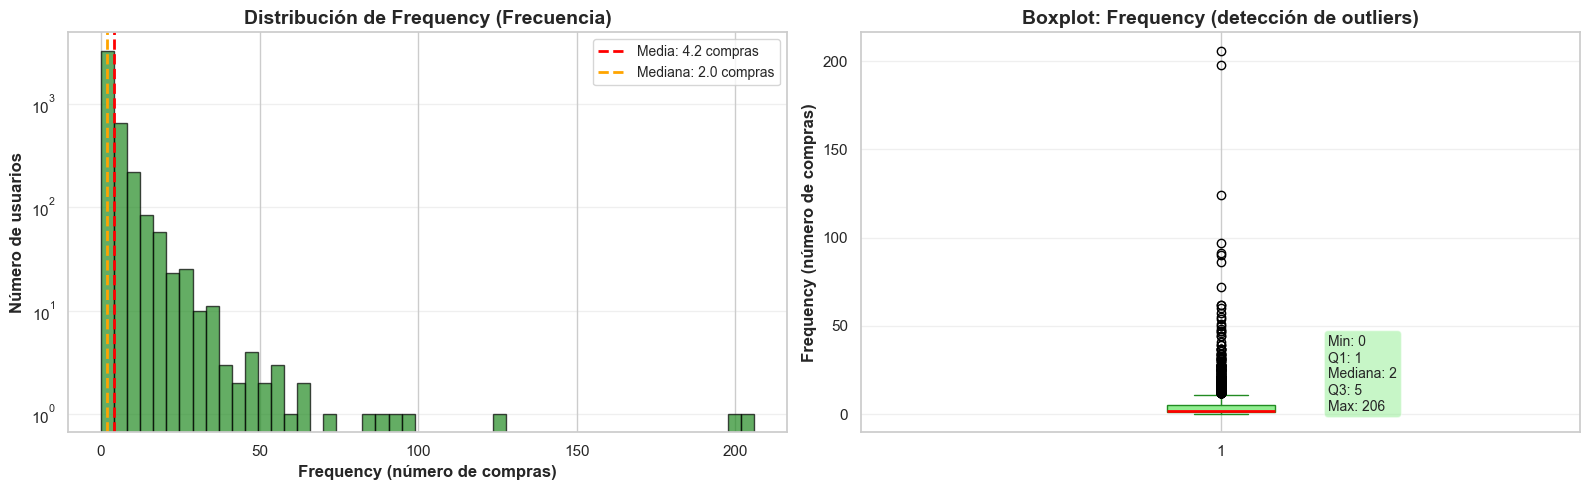

In [84]:
# ── Visualización de la distribución de Frequency ────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Frequency')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma (escala logarítmica en Y) ───────────────────────
axes[0].hist(df_rfm['Frequency'], bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_rfm["Frequency"].mean():.1f} compras')
axes[0].axvline(df_rfm['Frequency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df_rfm["Frequency"].median():.1f} compras')
axes[0].set_xlabel('Frequency (número de compras)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Frequency (Frecuencia)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
# Escala logarítmica en Y si hay mucha concentración en valores bajos
axes[0].set_yscale('log')

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Frequency'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='forestgreen'),
                whiskerprops=dict(color='forestgreen'),
                capprops=dict(color='forestgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Frequency (número de compras)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Frequency (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir estadísticas al boxplot
stats_text = f'Min: {df_rfm["Frequency"].min():.0f}\nQ1: {df_rfm["Frequency"].quantile(0.25):.0f}\nMediana: {df_rfm["Frequency"].median():.0f}\nQ3: {df_rfm["Frequency"].quantile(0.75):.0f}\nMax: {df_rfm["Frequency"].max():.0f}'
axes[1].text(1.15, df_rfm['Frequency'].median(), stats_text, fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()

# Guardar gráfico
ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.B_distribucion_frequency.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)

---

### 4.1.C — MONETARY (Valor Monetario)

**Definición**: Valor total gastado por el usuario en compras (excluyendo devoluciones)

**Interpretación**:
- Monetary **bajo** (ej. £10-50) → Cliente de bajo valor económico
- Monetary **alto** (ej. £5,000+) → Cliente de alto valor / VIP

**Cálculo**:
```
Monetary = sum(TotalPrice) por usuario, solo donde TotalPrice > 0
```

**Exclusión aplicada**: Se excluyen líneas con `Quantity < 0` (cancelaciones/devoluciones) para contabilizar únicamente el gasto real en compras.

**Nota**: `TotalPrice = Quantity × UnitPrice` ya fue calculado en el proceso de limpieza.

In [85]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.C: CÁLCULO DE MONETARY (VALOR MONETARIO)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.C: MONETARY (Valor Monetario)')
print('='*80)
print()

# ── 1. Filtrar solo líneas de compra (Quantity > 0) ──────────────────────────
print(f'Filtrando líneas de compra (excluir Quantity < 0)...')
print(f'  {'─'*78}')

total_lineas = len(df_transacciones)
print(f'     Total líneas (todas)              : {total_lineas:>10,}')

# Filtrar: solo líneas donde TotalPrice > 0 (compras reales, no devoluciones)
df_compras_monetario = df_transacciones[df_transacciones['TotalPrice'] > 0]
lineas_compra = len(df_compras_monetario)
print(f'     Líneas de COMPRA (TotalPrice > 0) : {lineas_compra:>10,}')

lineas_excluidas = total_lineas - lineas_compra
pct_excluidas = (lineas_excluidas / total_lineas * 100)
print(f'     Líneas EXCLUIDAS (devoluciones)   : {lineas_excluidas:>10,} ({pct_excluidas:.2f}%)')
print()

# ── 2. Calcular gasto total por usuario ──────────────────────────────────────
print(f'Calculando gasto total por usuario...')

monetary_por_usuario = df_compras_monetario.groupby('CustomerID')['TotalPrice'].sum()

print(f'   [OK] Monetary calculado para {len(monetary_por_usuario):,} usuarios')
print()

# ── 3. Agregar Monetary al DataFrame RFM ─────────────────────────────────────
print(f'Agregando Monetary al DataFrame RFM...')

df_rfm = df_rfm.merge(
    monetary_por_usuario.rename('Monetary'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)

# Rellenar con 0 si hay usuarios sin compras positivas
df_rfm['Monetary'] = df_rfm['Monetary'].fillna(0).round(2)

print(f'   [OK] Monetary agregado correctamente')
print()

print(f'[OK] DataFrame RFM actualizado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas descriptivas de Monetary ─────────────────────────────────
print(f'ESTADÍSTICAS DE MONETARY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : £{df_rfm["Monetary"].min():>12,.2f}  (gasto mínimo registrado)')
print(f'     Máximo         : £{df_rfm["Monetary"].max():>12,.2f}  (cliente de mayor gasto)')
print(f'     Media          : £{df_rfm["Monetary"].mean():>12,.2f}')
print(f'     Mediana        : £{df_rfm["Monetary"].median():>12,.2f}')
print(f'     Desv. estándar : £{df_rfm["Monetary"].std():>12,.2f}')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : £{df_rfm["Monetary"].quantile(0.25):>12,.2f}')
print(f'     P50 (Mediana)  : £{df_rfm["Monetary"].quantile(0.50):>12,.2f}')
print(f'     P75 (Q3)       : £{df_rfm["Monetary"].quantile(0.75):>12,.2f}')
print(f'     P90            : £{df_rfm["Monetary"].quantile(0.90):>12,.2f}')
print(f'     P95            : £{df_rfm["Monetary"].quantile(0.95):>12,.2f}')
print(f'     P99            : £{df_rfm["Monetary"].quantile(0.99):>12,.2f}')
print()

# ── 5. Distribución de usuarios por rango de Monetary ────────────────────────
print(f'DISTRIBUCIÓN DE USUARIOS POR RANGO DE MONETARY:')
print(f'  {'─'*78}')

bins_m   = [0, 100, 500, 1000, 2500, 5000, 10000, float('inf')]
labels_m = ['£0-100', '£100-500', '£500-1K', '£1K-2.5K', '£2.5K-5K', '£5K-10K', '£10K+']
df_rfm['Monetary_Range'] = pd.cut(df_rfm['Monetary'], bins=bins_m, labels=labels_m, right=True)

dist_m = df_rfm['Monetary_Range'].value_counts().sort_index()
for rango, count in dist_m.items():
    pct = (count / len(df_rfm) * 100)
    print(f'     {str(rango):<15} : {count:>6,} usuarios ({pct:>6.2f}%)')

df_rfm.drop('Monetary_Range', axis=1, inplace=True)

print()
print('='*80)

  PASO 4.1.C: MONETARY (Valor Monetario)

Filtrando líneas de compra (excluir Quantity < 0)...
  ──────────────────────────────────────────────────────────────────────────────
     Total líneas (todas)              :    399,651
     Líneas de COMPRA (TotalPrice > 0) :    391,145
     Líneas EXCLUIDAS (devoluciones)   :      8,506 (2.13%)

Calculando gasto total por usuario...
   [OK] Monetary calculado para 4,334 usuarios

Agregando Monetary al DataFrame RFM...
   [OK] Monetary agregado correctamente

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 4 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary']

ESTADÍSTICAS DE MONETARY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         : £        0.00  (gasto mínimo registrado)
     Máximo         : £  223,521.60  (cliente de mayor gasto)
     Media          : £    1,73


VISUALIZACIÓN: Distribución de Monetary

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.C_distribucion_monetary.png



VISUALIZACIÓN: Distribución de Monetary

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.C_distribucion_monetary.png


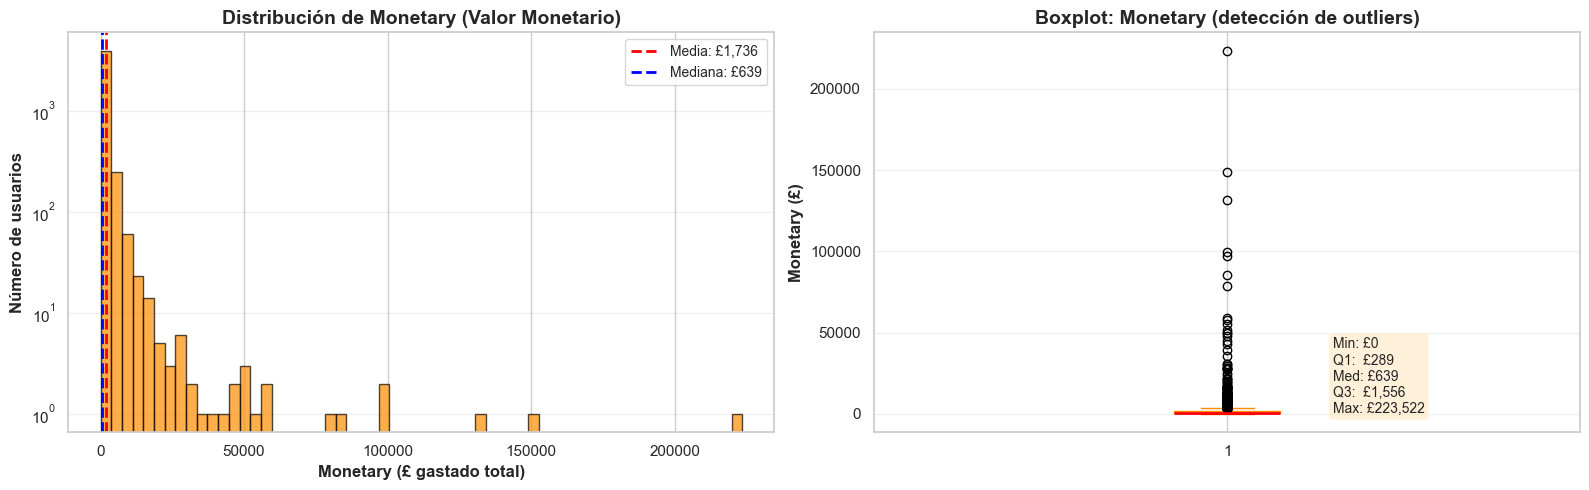

In [86]:
# ── Visualización de la distribución de Monetary ─────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Monetary')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma (escala logarítmica en Y) ──────────────────────────
axes[0].hist(df_rfm['Monetary'], bins=60, color='darkorange', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Monetary'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media: £{df_rfm["Monetary"].mean():,.0f}')
axes[0].axvline(df_rfm['Monetary'].median(), color='blue', linestyle='--', linewidth=2,
                label=f'Mediana: £{df_rfm["Monetary"].median():,.0f}')
axes[0].set_xlabel('Monetary (£ gastado total)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Monetary (Valor Monetario)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_yscale('log')

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Monetary'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='moccasin', color='darkorange'),
                whiskerprops=dict(color='darkorange'),
                capprops=dict(color='darkorange'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Monetary (£)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Monetary (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

stats_text = (f'Min: £{df_rfm["Monetary"].min():,.0f}\n'
              f'Q1:  £{df_rfm["Monetary"].quantile(0.25):,.0f}\n'
              f'Med: £{df_rfm["Monetary"].median():,.0f}\n'
              f'Q3:  £{df_rfm["Monetary"].quantile(0.75):,.0f}\n'
              f'Max: £{df_rfm["Monetary"].max():,.0f}')
axes[1].text(1.15, df_rfm['Monetary'].median(), stats_text, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='moccasin', alpha=0.5))

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.C_distribucion_monetary.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)

In [87]:
# ── Vista previa del DataFrame RFM completo (R + F + M) ──────────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM COMPLETO (Recency + Frequency + Monetary):')
print('='*80)
print()

print('TOP 10: Clientes de MAYOR VALOR (Monetary más alto):')
display(df_rfm.nlargest(10, 'Monetary'))

print()
print('TOP 10: Clientes de MENOR VALOR (Monetary más bajo):')
display(df_rfm.nsmallest(10, 'Monetary'))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10, random_state=42).sort_values('Monetary', ascending=False))

print()
print('RESUMEN ESTADÍSTICO COMPLETO DEL DATAFRAME RFM:')
print('─'*80)
display(df_rfm[['Recency', 'Frequency', 'Monetary']].describe())


VISTA PREVIA DEL DATAFRAME RFM COMPLETO (Recency + Frequency + Monetary):

TOP 10: Clientes de MAYOR VALOR (Monetary más alto):



VISTA PREVIA DEL DATAFRAME RFM COMPLETO (Recency + Frequency + Monetary):

TOP 10: Clientes de MAYOR VALOR (Monetary más alto):


,CustomerID,Recency,Frequency,Monetary
1699,14646.00,2,72,223521.60
4223,18102.00,1,60,149098.00
1891,14911.00,1,198,131859.82
55,12415.00,24,20,99547.57
1341,14156.00,10,54,97407.69
3792,17511.00,3,31,85314.24
3749,17450.00,8,46,78794.68
2188,15311.00,1,91,59213.71
566,13089.00,3,97,57512.36
1001,13694.00,4,50,55190.26



TOP 10: Clientes de MENOR VALOR (Monetary más bajo):


,CustomerID,Recency,Frequency,Monetary
210,12605.00,365,0,0.00
262,12666.00,359,0,0.00
413,12870.00,366,0,0.00
465,12943.00,301,0,0.00
1000,13693.00,325,0,0.00
1102,13829.00,359,0,0.00
1196,13958.00,372,0,0.00
1314,14119.00,354,0,0.00
1380,14213.00,372,0,0.00
1684,14627.00,312,0,0.00


...

,CustomerID,Recency,Frequency,Monetary
210,12605.00,365,0,0.00
262,12666.00,359,0,0.00
413,12870.00,366,0,0.00
465,12943.00,301,0,0.00
1000,13693.00,325,0,0.00
1102,13829.00,359,0,0.00
1196,13958.00,372,0,0.00
1314,14119.00,354,0,0.00
1380,14213.00,372,0,0.00
1684,14627.00,312,0,0.00



Muestra aleatoria de 10 usuarios:


,CustomerID,Recency,Frequency,Monetary
179,12572.00,9,2,904.02
3167,16644.00,178,2,833.78
2688,15994.00,55,1,410.07
2740,16063.00,260,1,335.32
2191,15314.00,199,1,327.97
2529,15766.00,64,1,315.06
1786,14764.00,44,1,278.30
2480,15703.00,265,1,211.50
1578,14485.00,39,1,162.80
3424,16988.00,5,1,126.12



RESUMEN ESTADÍSTICO COMPLETO DEL DATAFRAME RFM:
────────────────────────────────────────────────────────────────────────────────


,Recency,Frequency,Monetary
count,4362.00,4362.00,4362.00
mean,92.17,4.22,1736.02
std,100.97,7.62,6264.09
min,1.00,0.00,0.00
25%,17.00,1.00,288.99
50%,50.00,2.00,639.27
75%,143.00,5.00,1556.21
max,374.00,206.00,223521.60


---

## PASO 4.2: Variables de Comportamiento de Compra

Las variables RFM capturan el **qué** (cuánto, cuándo, cuántas veces), pero no el **cómo** compra el usuario. Las variables de comportamiento añaden profundidad al perfil:

### Por qué añadir variables de comportamiento

| Limitación del RFM puro | Variable que lo resuelve |
|-------------------------|--------------------------|
| Frequency ignora el tiempo: 10 compras en 1 mes ≠ 10 compras en 1 año | `frecuencia_mensual` |
| No distingue comprador regular de comprador esporádico | `dias_entre_compras` |
| No sabe si el usuario compra en varios meses o concentra todo en uno | `num_meses_activo` |

---

### 4.2.A — Frecuencia Temporal

**Variables a calcular**:

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `num_meses_activo` | Meses distintos en que el usuario realizó al menos una compra | `count(distinct Mes por usuario)` |
| `frecuencia_mensual` | Compras promedio por mes activo | `Frequency / num_meses_activo` |
| `dias_entre_compras` | Días promedio entre compras consecutivas | `periodo_activo / Frequency` |

**Notas de cálculo**:
- `periodo_activo` = días entre primera y última compra del usuario (no el dataset completo)
- Para usuarios con `Frequency = 1`, `dias_entre_compras = 0` (solo hay una compra, no hay intervalo)
- Solo se usan transacciones de **compra** (excluidas cancelaciones)

In [88]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.A: FRECUENCIA TEMPORAL
#   Variables: num_meses_activo, frecuencia_mensual, dias_entre_compras
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.A: FRECUENCIA TEMPORAL')
print('='*80)
print()

# Reutilizamos df_compras (ya filtrado: solo facturas sin 'C')
# Si no está en memoria, recalcular
df_compras = df_transacciones[~df_transacciones['InvoiceNo'].astype(str).str.startswith('C')]

# ── 1. num_meses_activo: Meses distintos en que compró ───────────────────────
print(f'Calculando num_meses_activo...')
print(f'  {'─'*78}')

# Extraer año-mes de la fecha para distinguir meses
df_compras = df_compras.copy()
df_compras['anio_mes'] = df_compras['InvoiceDate'].dt.to_period('M')

num_meses_activo = df_compras.groupby('CustomerID')['anio_mes'].nunique()

print(f'     [OK] Calculado para {len(num_meses_activo):,} usuarios')
print(f'     Rango: entre {num_meses_activo.min()} y {num_meses_activo.max()} meses activos')
print()

# ── 2. Calcular el periodo activo por usuario (primera a última compra) ──────
print(f'Calculando periodo activo por usuario (primera a última compra)...')

fecha_primera_compra = df_compras.groupby('CustomerID')['InvoiceDate'].min()
fecha_ultima_compra  = df_compras.groupby('CustomerID')['InvoiceDate'].max()
periodo_activo_dias  = (fecha_ultima_compra - fecha_primera_compra).dt.days

print(f'     [OK] Periodo activo calculado para {len(periodo_activo_dias):,} usuarios')
print()

# ── 3. frecuencia_mensual: Frequency / num_meses_activo ──────────────────────
print(f'Calculando frecuencia_mensual (compras por mes activo)...')

# Construir DataFrame auxiliar
df_temp = pd.DataFrame({
    'CustomerID'      : num_meses_activo.index,
    'num_meses_activo': num_meses_activo.values,
    'periodo_activo'  : periodo_activo_dias.values
})

# Merge con df_rfm para tener Frequency disponible
df_temp = df_temp.merge(df_rfm[['CustomerID', 'Frequency']], on='CustomerID', how='left')

# frecuencia_mensual = Frequency / num_meses_activo
df_temp['frecuencia_mensual'] = (df_temp['Frequency'] / df_temp['num_meses_activo']).round(2)

print(f'     [OK] frecuencia_mensual calculada')
print()

# ── 4. dias_entre_compras: periodo_activo / Frequency ────────────────────────
print(f'Calculando dias_entre_compras (días promedio entre compras)...')

# Para usuarios con Frequency = 1, el intervalo entre compras es 0 (solo 1 compra)
df_temp['dias_entre_compras'] = np.where(
    df_temp['Frequency'] <= 1,
    0,
    (df_temp['periodo_activo'] / (df_temp['Frequency'] - 1)).round(1)
)

print(f'     [OK] dias_entre_compras calculado')
print()

# ── 5. Merge al DataFrame principal df_rfm ───────────────────────────────────
print(f'Agregando variables al DataFrame RFM...')

df_rfm = df_rfm.merge(
    df_temp[['CustomerID', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras']],
    on='CustomerID',
    how='left'
)

# Rellenar posibles nulos
df_rfm['num_meses_activo']  = df_rfm['num_meses_activo'].fillna(0).astype(int)
df_rfm['frecuencia_mensual']= df_rfm['frecuencia_mensual'].fillna(0).round(2)
df_rfm['dias_entre_compras']= df_rfm['dias_entre_compras'].fillna(0).round(1)

print(f'   [OK] Variables agregadas correctamente')
print()

print(f'[OK] DataFrame RFM actualizado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 6. Estadísticas de las tres variables ────────────────────────────────────
print(f'ESTADÍSTICAS DE VARIABLES DE FRECUENCIA TEMPORAL:')
print(f'  {'─'*78}')

for col, unidad in [('num_meses_activo', 'meses'), ('frecuencia_mensual', 'compras/mes'), ('dias_entre_compras', 'días')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : {df_rfm[col].min():>8.1f} {unidad}')
    print(f'     Máximo    : {df_rfm[col].max():>8.1f} {unidad}')
    print(f'     Media     : {df_rfm[col].mean():>8.2f} {unidad}')
    print(f'     Mediana   : {df_rfm[col].median():>8.2f} {unidad}')

print()
print('='*80)

  PASO 4.2.A: FRECUENCIA TEMPORAL

Calculando num_meses_activo...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Calculado para 4,334 usuarios
     Rango: entre 1 y 13 meses activos

Calculando periodo activo por usuario (primera a última compra)...
     [OK] Periodo activo calculado para 4,334 usuarios

Calculando frecuencia_mensual (compras por mes activo)...
     [OK] frecuencia_mensual calculada

Calculando dias_entre_compras (días promedio entre compras)...
     [OK] dias_entre_compras calculado

Agregando variables al DataFrame RFM...
   [OK] Variables agregadas correctamente

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 7 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras']

ESTADÍSTICAS DE VARIABLES DE FRECUENCIA TEMPORAL:
  ────────────────────


VISUALIZACIÓN: Variables de Frecuencia Temporal

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.A_frecuencia_temporal.png



VISUALIZACIÓN: Variables de Frecuencia Temporal

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.A_frecuencia_temporal.png


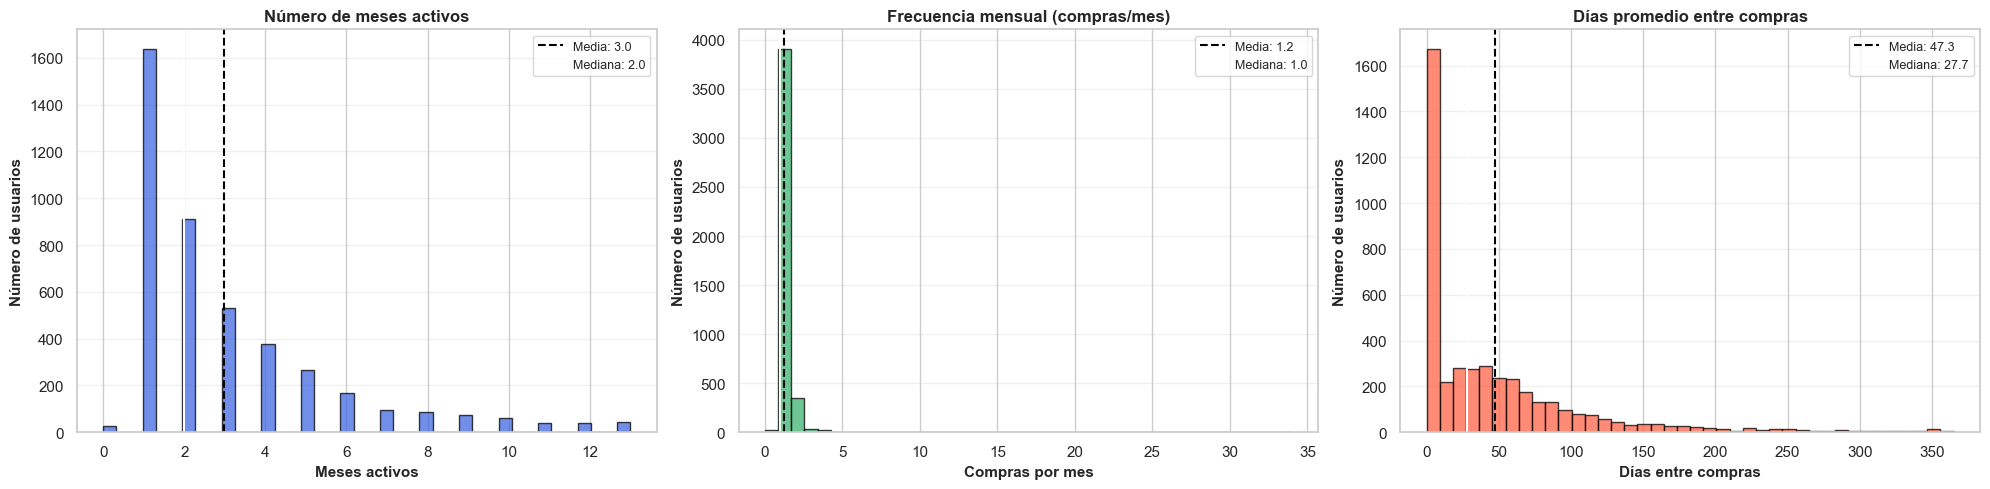

In [89]:
# ── Visualización de las variables de frecuencia temporal ────────────────────

print('\nVISUALIZACIÓN: Variables de Frecuencia Temporal')
print('='*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

variables = [
    ('num_meses_activo',   'Meses activos',            'Número de meses activos',         'royalblue'),
    ('frecuencia_mensual', 'Compras por mes',           'Frecuencia mensual (compras/mes)', 'mediumseagreen'),
    ('dias_entre_compras', 'Días entre compras',        'Días promedio entre compras',      'tomato'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=40, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black',  linestyle='--', linewidth=1.5,
               label=f'Media: {df_rfm[col].mean():.1f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {df_rfm[col].median():.1f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.A_frecuencia_temporal.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)


### 4.2.B — Valor de Compra

Las variables de frecuencia temporal nos dicen **cuándo** y **con qué regularidad** compra el usuario, pero no **cuánto gasta en cada visita** ni **cómo distribuye su gasto a lo largo del tiempo**. Estas dos variables complementan el Monetary del RFM añadiendo granularidad:

| Limitación del RFM puro | Variable que lo resuelve |
|-------------------------|--------------------------|
| Monetary alto puede deberse a muchas compras pequeñas o a pocas compras grandes | `ticket_promedio` |
| No sabemos si el gasto está concentrado en un mes o repartido a lo largo del año | `gasto_mensual` |

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `ticket_promedio` | Gasto medio por transacción (£ por compra) | `Monetary / Frequency` |
| `gasto_mensual` | Gasto medio por mes activo (£ por mes) | `Monetary / num_meses_activo` |

**Notas de cálculo**:
- Para usuarios con `Frequency = 0`, `ticket_promedio = 0`
- Para usuarios con `num_meses_activo = 0`, `gasto_mensual = 0`
- Ambas variables heredan el mismo filtro de Monetary (solo `TotalPrice > 0`)

In [90]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.B: VALOR DE COMPRA
#   Variables: ticket_promedio, gasto_mensual
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.B: VALOR DE COMPRA')
print('='*80)
print()

# ── 1. ticket_promedio: Monetary / Frequency ─────────────────────────────────
print('Calculando ticket_promedio (Monetary / Frequency)...')
print(f'  {"─"*78}')

df_rfm['ticket_promedio'] = np.where(
    df_rfm['Frequency'] == 0,
    0,
    (df_rfm['Monetary'] / df_rfm['Frequency']).round(2)
)

print(f'     [OK] ticket_promedio calculado para {len(df_rfm):,} usuarios')
print()

# ── 2. gasto_mensual: Monetary / num_meses_activo ────────────────────────────
print('Calculando gasto_mensual (Monetary / num_meses_activo)...')
print(f'  {"─"*78}')

df_rfm['gasto_mensual'] = np.where(
    df_rfm['num_meses_activo'] == 0,
    0,
    (df_rfm['Monetary'] / df_rfm['num_meses_activo']).round(2)
)

print(f'     [OK] gasto_mensual calculado para {len(df_rfm):,} usuarios')
print()

# ── 3. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas de las dos variables ─────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE VALOR DE COMPRA:')
print(f'  {"─"*78}')

for col, unidad in [('ticket_promedio', '£/compra'), ('gasto_mensual', '£/mes')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : £{df_rfm[col].min():>10,.2f}  ({unidad})')
    print(f'     Máximo    : £{df_rfm[col].max():>10,.2f}  ({unidad})')
    print(f'     Media     : £{df_rfm[col].mean():>10,.2f}  ({unidad})')
    print(f'     Mediana   : £{df_rfm[col].median():>10,.2f}  ({unidad})')
    print(f'     P75 (Q3)  : £{df_rfm[col].quantile(0.75):>10,.2f}  ({unidad})')
    print(f'     P95       : £{df_rfm[col].quantile(0.95):>10,.2f}  ({unidad})')

print()
print('='*80)

  PASO 4.2.B: VALOR DE COMPRA

Calculando ticket_promedio (Monetary / Frequency)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] ticket_promedio calculado para 4,362 usuarios

Calculando gasto_mensual (Monetary / num_meses_activo)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] gasto_mensual calculado para 4,362 usuarios

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 9 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras', 'ticket_promedio', 'gasto_mensual']

ESTADÍSTICAS DE VARIABLES DE VALOR DE COMPRA:
  ──────────────────────────────────────────────────────────────────────────────

  ticket_promedio:
     Mínimo    : £      0.00  (£/compra)
     Máximo    : £  9,029.26  (£/compra)
     Media     : £    349


VISUALIZACIÓN: Variables de Valor de Compra

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.B_valor_compra.png



VISUALIZACIÓN: Variables de Valor de Compra

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.B_valor_compra.png


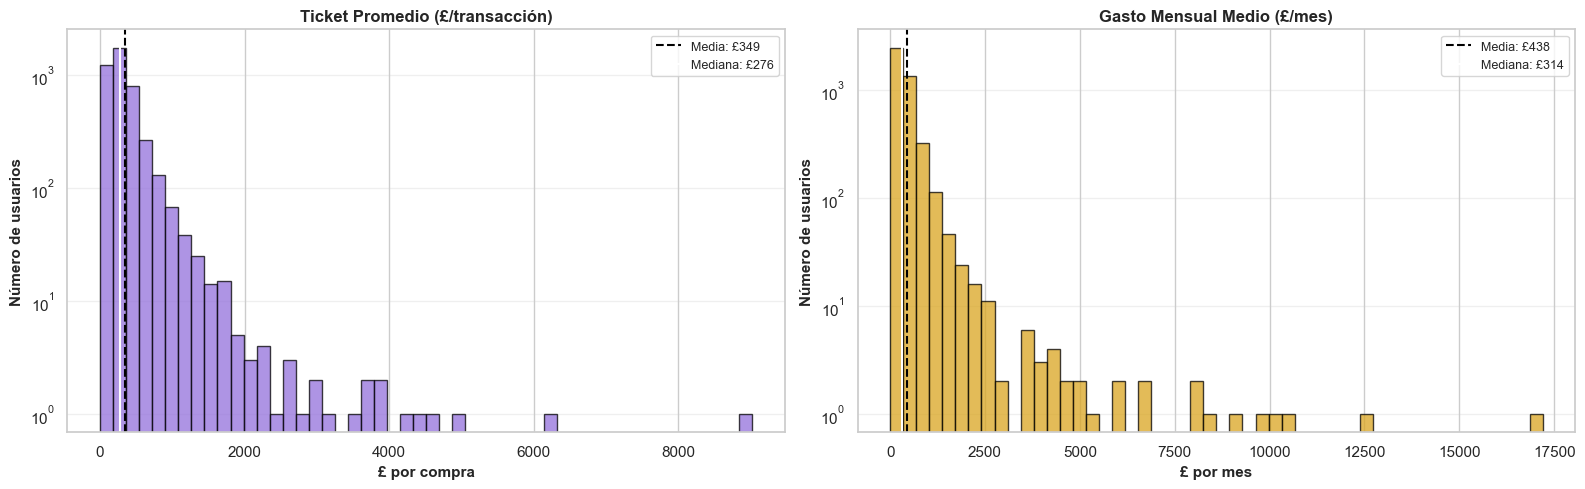

In [91]:
# ── Visualización de las variables de valor de compra ────────────────────────

print('\nVISUALIZACIÓN: Variables de Valor de Compra')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

variables = [
    ('ticket_promedio', '£ por compra',  'Ticket Promedio (£/transacción)', 'mediumpurple'),
    ('gasto_mensual',   '£ por mes',     'Gasto Mensual Medio (£/mes)',     'goldenrod'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Media: £{df_rfm[col].mean():,.0f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: £{df_rfm[col].median():,.0f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.B_valor_compra.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)

---

### 4.2.C — Diversidad de Productos

Frequency nos dice cuántas veces compra el usuario, pero no qué variedad de productos elige. Dos usuarios con la misma Frequency pueden tener perfiles muy distintos: uno compra siempre el mismo artículo, otro explora continuamente el catálogo.

| Limitación del RFM + variables anteriores | Variable que lo resuelve |
|-------------------------------------------|--------------------------|
| No distingue compradores especializados de compradores exploradores | `num_productos_unicos` |
| Frequency no informa sobre la amplitud del pedido medio | `diversidad_producto` |

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `num_productos_unicos` | Número de StockCode distintos comprados por el usuario | `count(distinct StockCode por usuario)` |
| `diversidad_producto` | Productos únicos promedio por transacción | `num_productos_unicos / Frequency` |

**Notas de cálculo**:
- Solo se usan transacciones de **compra** (sin cancelaciones)
- Para usuarios con `Frequency = 0`, `diversidad_producto = 0`

In [92]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.C: DIVERSIDAD DE PRODUCTOS
#   Variables: num_productos_unicos, diversidad_producto
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.C: DIVERSIDAD DE PRODUCTOS')
print('='*80)
print()

# df_compras ya está en memoria (transacciones sin cancelaciones)

# ── 1. num_productos_unicos: StockCode distintos por usuario ─────────────────
print('Calculando num_productos_unicos...')
print(f'  {"─"*78}')

num_productos_unicos = df_compras.groupby('CustomerID')['StockCode'].nunique()

print(f'     [OK] Calculado para {len(num_productos_unicos):,} usuarios')
print(f'     Rango: entre {num_productos_unicos.min()} y {num_productos_unicos.max()} productos únicos')
print()

# ── 2. Merge y calcular diversidad_producto ──────────────────────────────────
print('Calculando diversidad_producto (num_productos_unicos / Frequency)...')
print(f'  {"─"*78}')

df_rfm = df_rfm.merge(
    num_productos_unicos.rename('num_productos_unicos'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)
df_rfm['num_productos_unicos'] = df_rfm['num_productos_unicos'].fillna(0).astype(int)

df_rfm['diversidad_producto'] = np.where(
    df_rfm['Frequency'] == 0,
    0,
    (df_rfm['num_productos_unicos'] / df_rfm['Frequency']).round(2)
)

print(f'     [OK] diversidad_producto calculada')
print()

# ── 3. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas ──────────────────────────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE DIVERSIDAD:')
print(f'  {"─"*78}')

for col, unidad in [('num_productos_unicos', 'productos'), ('diversidad_producto', 'productos/compra')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : {df_rfm[col].min():>8.1f}  ({unidad})')
    print(f'     Máximo    : {df_rfm[col].max():>8.1f}  ({unidad})')
    print(f'     Media     : {df_rfm[col].mean():>8.2f}  ({unidad})')
    print(f'     Mediana   : {df_rfm[col].median():>8.2f}  ({unidad})')
    print(f'     P75 (Q3)  : {df_rfm[col].quantile(0.75):>8.2f}  ({unidad})')
    print(f'     P95       : {df_rfm[col].quantile(0.95):>8.2f}  ({unidad})')

print()
print('='*80)

  PASO 4.2.C: DIVERSIDAD DE PRODUCTOS

Calculando num_productos_unicos...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Calculado para 4,334 usuarios
     Rango: entre 1 y 1785 productos únicos

Calculando diversidad_producto (num_productos_unicos / Frequency)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] diversidad_producto calculada

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 11 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras', 'ticket_promedio', 'gasto_mensual', 'num_productos_unicos', 'diversidad_producto']

ESTADÍSTICAS DE VARIABLES DE DIVERSIDAD:
  ──────────────────────────────────────────────────────────────────────────────

  num_productos_unicos:
     Mínimo    :      0.0  (productos)
     


VISUALIZACIÓN: Variables de Diversidad de Productos

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.C_diversidad_producto.png



VISUALIZACIÓN: Variables de Diversidad de Productos

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.C_diversidad_producto.png


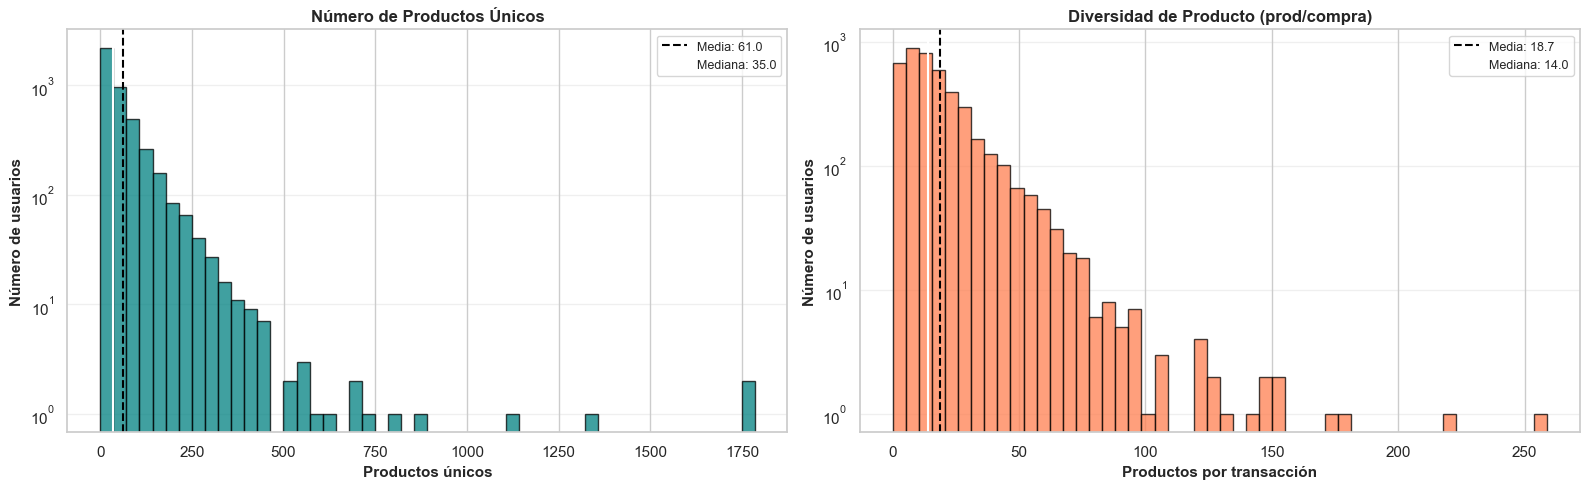

In [93]:
# ── Visualización de las variables de diversidad de productos ────────────────

print('\nVISUALIZACIÓN: Variables de Diversidad de Productos')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

variables = [
    ('num_productos_unicos', 'Productos únicos',         'Número de Productos Únicos',          'teal'),
    ('diversidad_producto',  'Productos por transacción','Diversidad de Producto (prod/compra)', 'coral'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {df_rfm[col].mean():.1f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {df_rfm[col].median():.1f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.C_diversidad_producto.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)

---

### 4.2.D — Cantidad de Productos

Las variables anteriores trabajan con el valor monetario y la diversidad, pero no con el **volumen físico** de lo que compra el usuario. Un usuario puede gastar mucho comprando pocos artículos caros, o poco comprando muchos artículos baratos. Esta variable captura el comportamiento de volumen.

| Limitación del RFM + variables anteriores | Variable que lo resuelve |
|-------------------------------------------|--------------------------|
| Monetary y ticket_promedio son valores monetarios, no dicen cuántas unidades compra | `cantidad_total_comprada` |
| No sabemos si el usuario hace pedidos grandes o pequeños de media | `cantidad_promedio_por_compra` |

<br>

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `cantidad_total_comprada` | Total de unidades compradas por el usuario | `sum(Quantity > 0 por usuario)` |
| `cantidad_promedio_por_compra` | Unidades medias por transacción | `cantidad_total_comprada / Frequency` |

**Notas de cálculo**:
- Solo se suman cantidades positivas (`Quantity > 0`), excluyendo devoluciones
- Para usuarios con `Frequency = 0`, `cantidad_promedio_por_compra = 0`

In [94]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.D: CANTIDAD DE PRODUCTOS
#   Variables: cantidad_total_comprada, cantidad_promedio_por_compra
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.D: CANTIDAD DE PRODUCTOS')
print('='*80)
print()

# ── 1. cantidad_total_comprada: sum(Quantity > 0) por usuario ─────────────────
print('Calculando cantidad_total_comprada...')
print(f'  {"─"*78}')

# Filtrar solo líneas con cantidad positiva (compras reales)
df_compras_cantidad = df_compras[df_compras['Quantity'] > 0]

cantidad_total = df_compras_cantidad.groupby('CustomerID')['Quantity'].sum()

print(f'     [OK] Calculado para {len(cantidad_total):,} usuarios')
print(f'     Rango: entre {cantidad_total.min():,} y {cantidad_total.max():,} unidades')
print()

# ── 2. Merge y calcular cantidad_promedio_por_compra ─────────────────────────
print('Calculando cantidad_promedio_por_compra (cantidad_total / Frequency)...')
print(f'  {"─"*78}')

df_rfm = df_rfm.merge(
    cantidad_total.rename('cantidad_total_comprada'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)
df_rfm['cantidad_total_comprada'] = df_rfm['cantidad_total_comprada'].fillna(0).astype(int)

df_rfm['cantidad_promedio_por_compra'] = np.where(
    df_rfm['Frequency'] == 0,
    0,
    (df_rfm['cantidad_total_comprada'] / df_rfm['Frequency']).round(1)
)

print(f'     [OK] cantidad_promedio_por_compra calculada')
print()

# ── 3. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas ──────────────────────────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE CANTIDAD:')
print(f'  {"─"*78}')

for col, unidad in [('cantidad_total_comprada', 'unidades'), ('cantidad_promedio_por_compra', 'unidades/compra')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : {df_rfm[col].min():>10.1f}  ({unidad})')
    print(f'     Máximo    : {df_rfm[col].max():>10.1f}  ({unidad})')
    print(f'     Media     : {df_rfm[col].mean():>10.2f}  ({unidad})')
    print(f'     Mediana   : {df_rfm[col].median():>10.2f}  ({unidad})')
    print(f'     P75 (Q3)  : {df_rfm[col].quantile(0.75):>10.2f}  ({unidad})')
    print(f'     P95       : {df_rfm[col].quantile(0.95):>10.2f}  ({unidad})')

print()
print('='*80)

  PASO 4.2.D: CANTIDAD DE PRODUCTOS

Calculando cantidad_total_comprada...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Calculado para 4,334 usuarios
     Rango: entre 1 y 147,618 unidades

Calculando cantidad_promedio_por_compra (cantidad_total / Frequency)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] cantidad_promedio_por_compra calculada

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 13 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras', 'ticket_promedio', 'gasto_mensual', 'num_productos_unicos', 'diversidad_producto', 'cantidad_total_comprada', 'cantidad_promedio_por_compra']

ESTADÍSTICAS DE VARIABLES DE CANTIDAD:
  ──────────────────────────────────────────────────────────────────────────────

  c


VISUALIZACIÓN: Variables de Cantidad de Productos

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.D_cantidad_productos.png



VISUALIZACIÓN: Variables de Cantidad de Productos

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.D_cantidad_productos.png


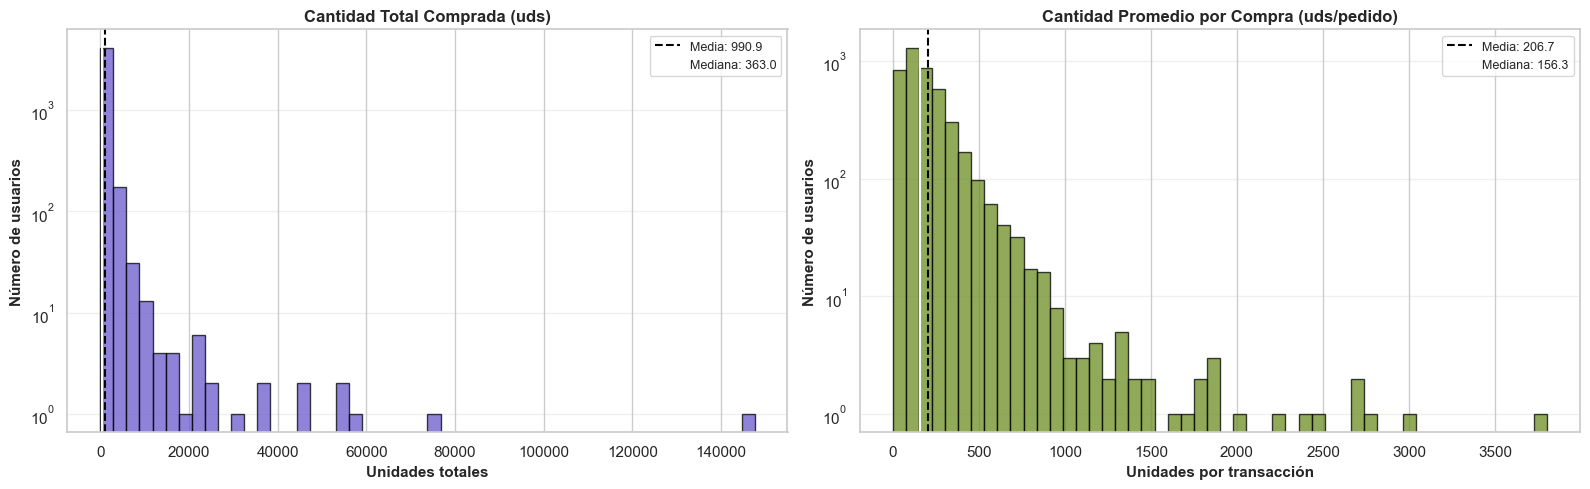

In [95]:
# ── Visualización de las variables de cantidad ───────────────────────────────

print('\nVISUALIZACIÓN: Variables de Cantidad de Productos')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

variables = [
    ('cantidad_total_comprada',     'Unidades totales',      'Cantidad Total Comprada (uds)',          'slateblue'),
    ('cantidad_promedio_por_compra','Unidades por transacción','Cantidad Promedio por Compra (uds/pedido)', 'olivedrab'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {df_rfm[col].mean():.1f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {df_rfm[col].median():.1f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.D_cantidad_productos.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)

---

## PASO 4.3: Variables de Comportamiento de Devolución

Las cancelaciones están **conservadas** en el dataset (columna `EsCancelacion` + InvoiceNo comenzando por 'C'). Esto permite calcular el perfil de devolución de cada usuario, un indicador diferenciador clave: un cliente con alta tasa de cancelación puede reflejar insatisfacción, compra por impulso o abuso del sistema de devoluciones.

**Decisión: OPCION A — INCLUIR features de cancelación** (recomendado)

| Por qué incluir variables de devolución | Valor para el clustering |
|-----------------------------------------|--------------------------|
| Frequency=20 con 15 cancelaciones es muy distinto a Frequency=20 con 0 cancelaciones | Distingue clientes fieles de clientes problemáticos |
| El valor monetario devuelto afecta el valor neto real del cliente | Complementa el Monetary del RFM |

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `num_cancelaciones` | Número de facturas canceladas por el usuario | `count(EsCancelacion == True por usuario)` |
| `tasa_cancelacion` | % de transacciones que son devoluciones | `num_cancelaciones / Frequency` |
| `valor_devuelto` | Valor monetario total devuelto (en positivo) | `abs(sum(TotalPrice < 0 por usuario))` |
| `ratio_devolucion_monetario` | % de dinero devuelto sobre el total gastado | `valor_devuelto / Monetary` |


**Notas de cálculo**:- Ambas tasas pueden superar 1.0 si las cancelaciones superan en número/valor a las compras

- `num_cancelaciones` usa `EsCancelacion == True` (equivalente a InvoiceNo con 'C')- `ratio_devolucion_monetario = 0` para usuarios con `Monetary = 0`
- `tasa_cancelacion = 0` para usuarios con `Frequency = 0`

In [96]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.3: VARIABLES DE COMPORTAMIENTO DE DEVOLUCIÓN
#   Variables: num_cancelaciones, tasa_cancelacion, valor_devuelto,
#              ratio_devolucion_monetario
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.3: VARIABLES DE COMPORTAMIENTO DE DEVOLUCIÓN')
print('='*80)
print()

# ── 1. Filtrar cancelaciones usando columna EsCancelacion ────────────────────
print('Identificando transacciones de cancelación...')
print(f'  {"─"*78}')

df_cancelaciones = df_transacciones[df_transacciones['EsCancelacion'] == True]

total_cancelaciones = df_cancelaciones['InvoiceNo'].nunique()
usuarios_con_cancelaciones = df_cancelaciones['CustomerID'].nunique()

print(f'     Facturas de cancelación únicas  : {total_cancelaciones:>8,}')
print(f'     Usuarios con al menos 1 cancel. : {usuarios_con_cancelaciones:>8,}')
print(f'     Usuarios sin cancelaciones      : {len(df_rfm) - usuarios_con_cancelaciones:>8,}')
print()

# ── 2. num_cancelaciones: count facturas únicas canceladas por usuario ───────
print('Calculando num_cancelaciones...')
print(f'  {"─"*78}')

num_cancelaciones_serie = df_cancelaciones.groupby('CustomerID')['InvoiceNo'].nunique()

df_rfm = df_rfm.merge(
    num_cancelaciones_serie.rename('num_cancelaciones'),
    left_on='CustomerID', right_index=True, how='left'
)
df_rfm['num_cancelaciones'] = df_rfm['num_cancelaciones'].fillna(0).astype(int)

print(f'     [OK] num_cancelaciones calculado')
print()

# ── 3. tasa_cancelacion: num_cancelaciones / Frequency ───────────────────────
print('Calculando tasa_cancelacion (num_cancelaciones / Frequency)...')
print(f'  {"─"*78}')

df_rfm['tasa_cancelacion'] = np.where(
    df_rfm['Frequency'] == 0,
    0,
    (df_rfm['num_cancelaciones'] / df_rfm['Frequency']).round(4)
)

print(f'     [OK] tasa_cancelacion calculada')
print()

# ── 4. valor_devuelto: abs(sum(TotalPrice < 0)) por usuario ─────────────────
print('Calculando valor_devuelto (abs de suma de TotalPrice negativos)...')
print(f'  {"─"*78}')

df_negativos = df_transacciones[df_transacciones['TotalPrice'] < 0]
valor_devuelto_serie = df_negativos.groupby('CustomerID')['TotalPrice'].sum().abs()

df_rfm = df_rfm.merge(
    valor_devuelto_serie.rename('valor_devuelto'),
    left_on='CustomerID', right_index=True, how='left'
)
df_rfm['valor_devuelto'] = df_rfm['valor_devuelto'].fillna(0).round(2)

print(f'     [OK] valor_devuelto calculado')
print()

# ── 5. ratio_devolucion_monetario: valor_devuelto / Monetary ─────────────────
print('Calculando ratio_devolucion_monetario (valor_devuelto / Monetary)...')
print(f'  {"─"*78}')

df_rfm['ratio_devolucion_monetario'] = np.where(
    df_rfm['Monetary'] == 0,
    0,
    (df_rfm['valor_devuelto'] / df_rfm['Monetary']).round(4)
)

print(f'     [OK] ratio_devolucion_monetario calculado')
print()

# ── 6. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 7. Estadísticas ──────────────────────────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE DEVOLUCIÓN:')
print(f'  {"─"*78}')

print(f'\n  num_cancelaciones:')
print(f'     Sin cancelaciones (= 0) : {(df_rfm["num_cancelaciones"] == 0).sum():>8,} ({(df_rfm["num_cancelaciones"] == 0).mean()*100:.1f}%)')
print(f'     Con cancelaciones (>= 1): {(df_rfm["num_cancelaciones"] >= 1).sum():>8,} ({(df_rfm["num_cancelaciones"] >= 1).mean()*100:.1f}%)')
print(f'     Máximo                  : {df_rfm["num_cancelaciones"].max():>8,}')
print(f'     Media                   : {df_rfm["num_cancelaciones"].mean():>8.2f}')

print(f'\n  tasa_cancelacion (cancelaciones / Frequency):')
print(f'     Tasa = 0 (sin cancelac.): {(df_rfm["tasa_cancelacion"] == 0).sum():>8,} ({(df_rfm["tasa_cancelacion"] == 0).mean()*100:.1f}%)')
print(f'     Tasa > 1.0              : {(df_rfm["tasa_cancelacion"] > 1.0).sum():>8,} (más cancelac. que compras)')
print(f'     Máxima                  : {df_rfm["tasa_cancelacion"].max():>8.4f}')
print(f'     Media                   : {df_rfm["tasa_cancelacion"].mean():>8.4f}')

print(f'\n  valor_devuelto (£):')
print(f'     Sin devolución (= 0)    : {(df_rfm["valor_devuelto"] == 0).sum():>8,} ({(df_rfm["valor_devuelto"] == 0).mean()*100:.1f}%)')
print(f'     Máximo                  : £{df_rfm["valor_devuelto"].max():>10,.2f}')
print(f'     Media (entre todos)     : £{df_rfm["valor_devuelto"].mean():>10,.2f}')

print(f'\n  ratio_devolucion_monetario (valor_devuelto / Monetary):')
print(f'     Ratio = 0               : {(df_rfm["ratio_devolucion_monetario"] == 0).sum():>8,} ({(df_rfm["ratio_devolucion_monetario"] == 0).mean()*100:.1f}%)')
print(f'     Máximo                  : {df_rfm["ratio_devolucion_monetario"].max():>8.4f}')
print(f'     Media                   : {df_rfm["ratio_devolucion_monetario"].mean():>8.4f}')

print()
print('='*80)

  PASO 4.3: VARIABLES DE COMPORTAMIENTO DE DEVOLUCIÓN

Identificando transacciones de cancelación...
  ──────────────────────────────────────────────────────────────────────────────
     Facturas de cancelación únicas  :    3,383
     Usuarios con al menos 1 cancel. :    1,534
     Usuarios sin cancelaciones      :    2,828

Calculando num_cancelaciones...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] num_cancelaciones calculado

Calculando tasa_cancelacion (num_cancelaciones / Frequency)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] tasa_cancelacion calculada

Calculando valor_devuelto (abs de suma de TotalPrice negativos)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] valor_devuelto calculado

Calculando ratio_devolucion_monetario (valor_devuelto / Monetary)...
  ──────────────────────────────────────────────────────────────────────────────
     


VISUALIZACIÓN: Variables de Comportamiento de Devolución

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.3_variables_devolucion.png



VISUALIZACIÓN: Variables de Comportamiento de Devolución

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.3_variables_devolucion.png


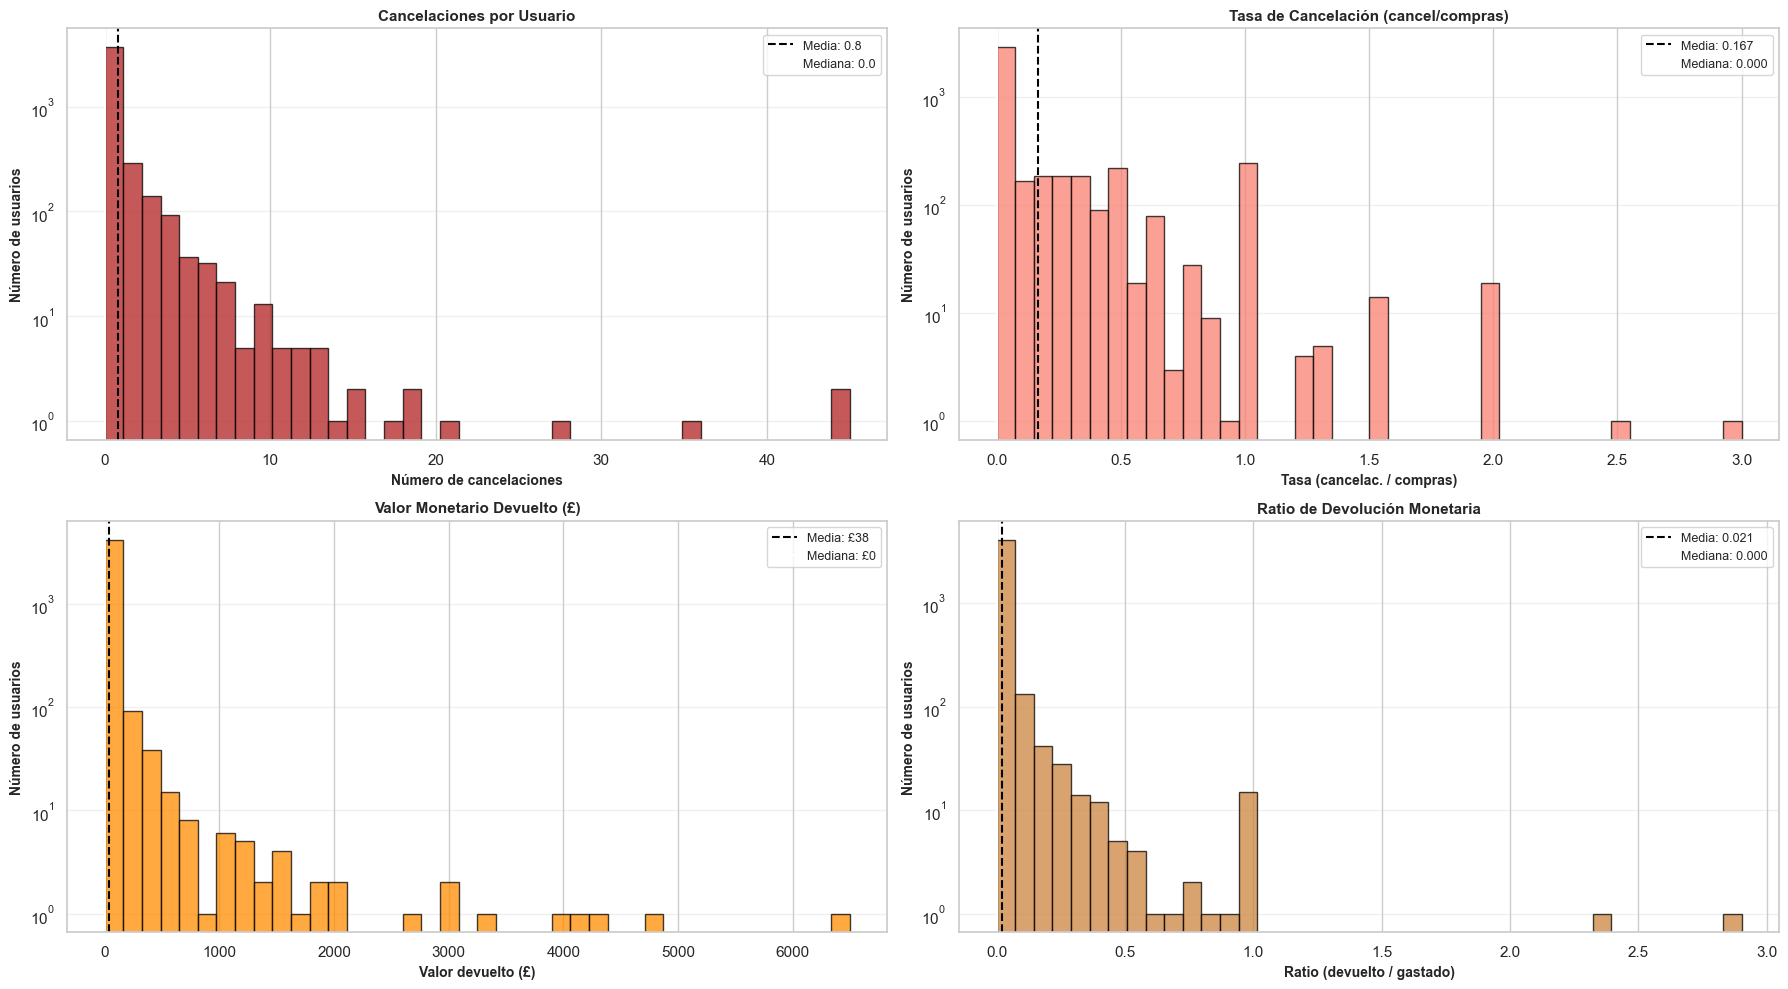

In [97]:
# ── Visualización de las variables de devolución ─────────────────────────────

print('\nVISUALIZACIÓN: Variables de Comportamiento de Devolución')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

variables_dev = [
    ('num_cancelaciones',        'Número de cancelaciones',      'Cancelaciones por Usuario',                  'firebrick',  '{:.1f}'),
    ('tasa_cancelacion',         'Tasa (cancelac. / compras)',    'Tasa de Cancelación (cancel/compras)',        'salmon',     '{:.3f}'),
    ('valor_devuelto',           'Valor devuelto (£)',            'Valor Monetario Devuelto (£)',                'darkorange', '£{:.0f}'),
    ('ratio_devolucion_monetario','Ratio (devuelto / gastado)',   'Ratio de Devolución Monetaria',              'peru',       '{:.3f}'),
]

for ax, (col, xlabel, title, color, fmt) in zip(axes, variables_dev):
    ax.hist(df_rfm[col], bins=40, color=color, edgecolor='black', alpha=0.75)
    media   = df_rfm[col].mean()
    mediana = df_rfm[col].median()
    ax.axvline(media,   color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {fmt.format(media)}')
    ax.axvline(mediana, color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {fmt.format(mediana)}')
    ax.set_xlabel(xlabel, fontsize=10, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.3_variables_devolucion.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)

## PASO 4.4: Variables de Comportamiento Temporal

RFM registra *cuándo fue la última compra* (Recency) pero no *en qué momento del ciclo semanal* compra el usuario. El patrón temporal semanal permite distinguir perfiles de clientes muy diferentes en términos de disponibilidad y hábitos de consumo.

### Qué añade este paso

| Dimensión | RFM captura | 4.4 añade |
|-----------|-------------|-----------|
| Día favorito | — | `dia_semana_mas_frecuente` |
| Compras en fin de semana | — | `compras_fin_semana` |
| Proporción fin de semana | — | `ratio_fin_semana` |

### Variables definidas

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `dia_semana_mas_frecuente` | Día de la semana en que el usuario compra con más frecuencia | `mode(DiaSemana)` por usuario en df_compras |
| `compras_fin_semana` | Número de facturas únicas realizadas en sábado o domingo | `nunique(InvoiceNo)` donde `DiaSemana ∈ {Saturday, Sunday}` |
| `ratio_fin_semana` | Proporción de compras que ocurren en fin de semana | `compras_fin_semana / Frequency` |

> **Nota encoding:** `dia_semana_mas_frecuente` es texto (Monday … Sunday). Recibirá One-Hot Encoding en PASO 7.  
> Fuente: columna `DiaSemana` de `df_compras` (transacciones sin cancelaciones).

In [98]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.4: VARIABLES DE COMPORTAMIENTO TEMPORAL
#   Variables: dia_semana_mas_frecuente, compras_fin_semana, ratio_fin_semana
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.4: VARIABLES DE COMPORTAMIENTO TEMPORAL')
print('='*80)
print()

DIAS_ORDEN = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# ── 4.4.A: dia_semana_mas_frecuente ─────────────────────────────────────────
print('4.4.A — Calculando dia_semana_mas_frecuente...')
print(f'  {"─"*78}')

# Para cada usuario, el día en que aparece más veces en sus líneas de compra
dia_semana_serie = (
    df_compras
    .groupby('CustomerID')['DiaSemana']
    .agg(lambda x: x.value_counts().index[0])
)

df_rfm = df_rfm.merge(
    dia_semana_serie.rename('dia_semana_mas_frecuente'),
    left_on='CustomerID', right_index=True, how='left'
)
# Usuarios sin compras (Frequency == 0) → 'Unknown'
df_rfm['dia_semana_mas_frecuente'] = df_rfm['dia_semana_mas_frecuente'].fillna('Unknown')

print(f'     [OK] dia_semana_mas_frecuente calculado')

dist_dias = df_rfm['dia_semana_mas_frecuente'].value_counts()
for dia in DIAS_ORDEN:
    n = dist_dias.get(dia, 0)
    print(f'     {dia:<12} : {n:>5,} usuarios ({n/len(df_rfm)*100:.1f}%)')
unknown = dist_dias.get('Unknown', 0)
if unknown:
    print(f'     {"Unknown":<12} : {unknown:>5,} usuarios ({unknown/len(df_rfm)*100:.1f}%)')
print()

# ── 4.4.B: compras_fin_semana ────────────────────────────────────────────────
print('4.4.B — Calculando compras_fin_semana (facturas únicas en sáb o dom)...')
print(f'  {"─"*78}')

df_finde = df_compras[df_compras['DiaSemana'].isin(['Saturday', 'Sunday'])]
compras_fin_semana_serie = df_finde.groupby('CustomerID')['InvoiceNo'].nunique()

df_rfm = df_rfm.merge(
    compras_fin_semana_serie.rename('compras_fin_semana'),
    left_on='CustomerID', right_index=True, how='left'
)
df_rfm['compras_fin_semana'] = df_rfm['compras_fin_semana'].fillna(0).astype(int)

usuarios_con_finde = (df_rfm['compras_fin_semana'] > 0).sum()
print(f'     [OK] compras_fin_semana calculado')
print(f'     Usuarios con al menos 1 compra en finde : {usuarios_con_finde:>6,} ({usuarios_con_finde/len(df_rfm)*100:.1f}%)')
print(f'     Usuarios sin compras en finde           : {len(df_rfm) - usuarios_con_finde:>6,}')
print(f'     Máximo compras en finde                 : {df_rfm["compras_fin_semana"].max():>6,}')
print(f'     Media                                   : {df_rfm["compras_fin_semana"].mean():>6.2f}')
print()

# ── 4.4.B: ratio_fin_semana ──────────────────────────────────────────────────
print('4.4.B — Calculando ratio_fin_semana (compras_fin_semana / Frequency)...')
print(f'  {"─"*78}')

df_rfm['ratio_fin_semana'] = np.where(
    df_rfm['Frequency'] == 0,
    0.0,
    (df_rfm['compras_fin_semana'] / df_rfm['Frequency']).round(4)
)

print(f'     [OK] ratio_fin_semana calculado')
print(f'     Ratio = 0 (sin finde)   : {(df_rfm["ratio_fin_semana"] == 0).sum():>6,} ({(df_rfm["ratio_fin_semana"] == 0).mean()*100:.1f}%)')
print(f'     Ratio = 1 (solo finde)  : {(df_rfm["ratio_fin_semana"] == 1).sum():>6,} ({(df_rfm["ratio_fin_semana"] == 1).mean()*100:.1f}%)')
print(f'     Máximo                  : {df_rfm["ratio_fin_semana"].max():>6.4f}')
print(f'     Media                   : {df_rfm["ratio_fin_semana"].mean():>6.4f}')
print()

# ── Estado actual del DataFrame ───────────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

  PASO 4.4: VARIABLES DE COMPORTAMIENTO TEMPORAL

4.4.A — Calculando dia_semana_mas_frecuente...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] dia_semana_mas_frecuente calculado
     Monday       :   681 usuarios (15.6%)
     Tuesday      :   706 usuarios (16.2%)
     Wednesday    :   776 usuarios (17.8%)
     Thursday     :   968 usuarios (22.2%)
     Friday       :   621 usuarios (14.2%)
     Saturday     :     0 usuarios (0.0%)
     Sunday       :   582 usuarios (13.3%)
     Unknown      :    28 usuarios (0.6%)

4.4.B — Calculando compras_fin_semana (facturas únicas en sáb o dom)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] compras_fin_semana calculado
     Usuarios con al menos 1 compra en finde :  1,225 (28.1%)
     Usuarios sin compras en finde           :  3,137
     Máximo compras en finde                 :     23
     Media                                   :   0.50

4.4.B — Calculand

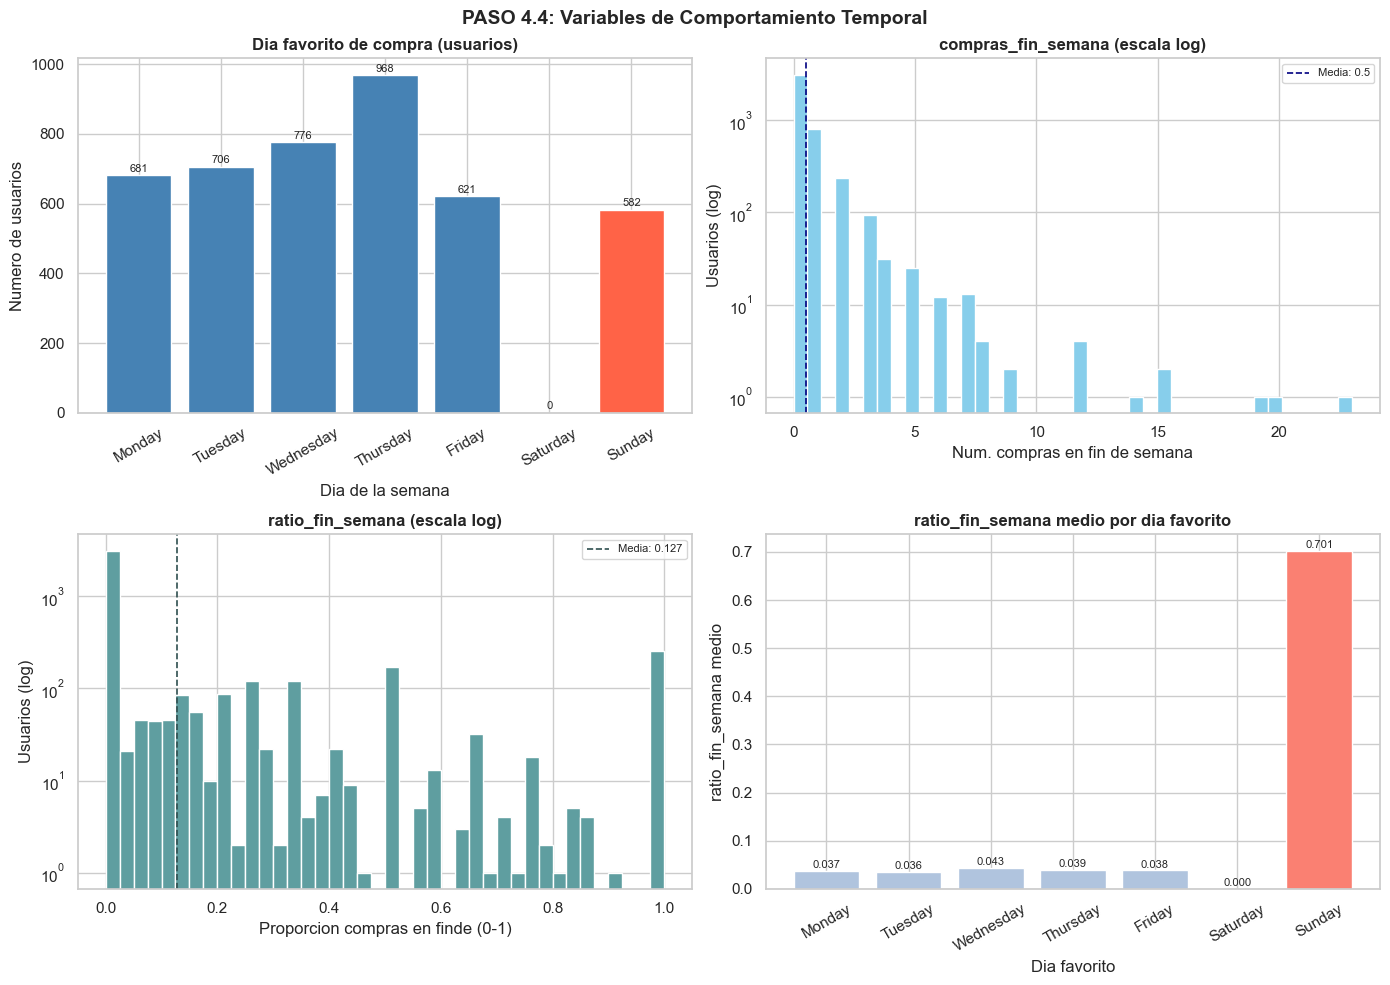

[OK] Grafico guardado en: ../../../graphics/gr_clustering/preprocesing/4.4_variables_temporales.png


In [99]:
# ── Visualización PASO 4.4 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PASO 4.4: Variables de Comportamiento Temporal', fontsize=14, fontweight='bold')

DIAS_ORDEN = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# [0,0] Distribución de dia_semana_mas_frecuente por usuario
ax = axes[0, 0]
dist_dias = df_rfm['dia_semana_mas_frecuente'].value_counts().reindex(DIAS_ORDEN, fill_value=0)
colores_dias = ['steelblue'] * 5 + ['tomato', 'tomato']   # finde en rojo
ax.bar(dist_dias.index, dist_dias.values, color=colores_dias, edgecolor='white')
ax.set_title('Dia favorito de compra (usuarios)', fontweight='bold')
ax.set_xlabel('Dia de la semana')
ax.set_ylabel('Numero de usuarios')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(dist_dias.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8)

# [0,1] Histograma compras_fin_semana (log Y)
ax = axes[0, 1]
ax.hist(df_rfm['compras_fin_semana'], bins=40, color='skyblue', edgecolor='white')
ax.set_yscale('log')
ax.set_title('compras_fin_semana (escala log)', fontweight='bold')
ax.set_xlabel('Num. compras en fin de semana')
ax.set_ylabel('Usuarios (log)')
media_finde = df_rfm['compras_fin_semana'].mean()
ax.axvline(media_finde, color='navy', linestyle='--', linewidth=1.2,
           label=f'Media: {media_finde:.1f}')
ax.legend(fontsize=8)

# [1,0] Histograma ratio_fin_semana (log Y)
ax = axes[1, 0]
ax.hist(df_rfm['ratio_fin_semana'], bins=40, color='cadetblue', edgecolor='white')
ax.set_yscale('log')
ax.set_title('ratio_fin_semana (escala log)', fontweight='bold')
ax.set_xlabel('Proporcion compras en finde (0-1)')
ax.set_ylabel('Usuarios (log)')
media_ratio = df_rfm['ratio_fin_semana'].mean()
ax.axvline(media_ratio, color='darkslategray', linestyle='--', linewidth=1.2,
           label=f'Media: {media_ratio:.3f}')
ax.legend(fontsize=8)

# [1,1] ratio_fin_semana medio por dia_semana_mas_frecuente
ax = axes[1, 1]
ratio_por_dia = (
    df_rfm[df_rfm['dia_semana_mas_frecuente'].isin(DIAS_ORDEN)]
    .groupby('dia_semana_mas_frecuente')['ratio_fin_semana']
    .mean()
    .reindex(DIAS_ORDEN, fill_value=0)
)
colores_ratio = ['lightsteelblue'] * 5 + ['salmon', 'salmon']
ax.bar(ratio_por_dia.index, ratio_por_dia.values, color=colores_ratio, edgecolor='white')
ax.set_title('ratio_fin_semana medio por dia favorito', fontweight='bold')
ax.set_xlabel('Dia favorito')
ax.set_ylabel('ratio_fin_semana medio')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(ratio_por_dia.values):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
ruta_grafico = RUTA_GRAFICOS + '4.4_variables_temporales.png'
plt.savefig(ruta_grafico, dpi=120, bbox_inches='tight')
plt.show()
print(f'[OK] Grafico guardado en: {ruta_grafico}')

## PASO 4.5: Variable Geográfica

RFM y las variables de comportamiento no recogen información sobre el **origen geográfico** del cliente. El país puede ser un proxy de patrones culturales de consumo, temporadas diferentes o canales de distribución distintos.

### Decisión: OPCION A — INCLUIR (recomendado)

| Criterio | Razonamiento |
|----------|--------------|
| Relevancia | País correlaciona con hábitos de compra, estacionalidad y poder adquisitivo |
| Problema | One-Hot encoding genera muchas columnas si hay muchos países |
| Solución | Agrupar países con < 1% de usuarios en categoria `"Otros"` |
| Resultado esperado | UK dominante (~90%) + un puñado de países frecuentes + `Otros` |

### Variable definida

| Variable | Definición | Fórmula | Encoding |
|----------|------------|---------|---------|
| `pais` | País más frecuente del usuario a lo largo de todas sus transacciones | `mode(Country)` por usuario en `df_transacciones` | One-Hot (PASO 7) |

> **Umbral de agrupación:** países con < 1% del total de usuarios → `"Otros"`.  
> Se usa `df_transacciones` (no `df_compras`) para capturar también las sesiones con devoluciones.

In [100]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.5: VARIABLE GEOGRÁFICA
#   Variable: pais (mode de Country por usuario, minoritarios → "Otros")
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.5: VARIABLE GEOGRÁFICA')
print('='*80)
print()

# ── 1. País más frecuente por usuario ────────────────────────────────────────
print('Calculando pais mas frecuente por usuario (mode de Country)...')
print(f'  {"─"*78}')

pais_serie = (
    df_transacciones
    .groupby('CustomerID')['Country']
    .agg(lambda x: x.value_counts().index[0])
)

print(f'     [OK] Pais calculado para {pais_serie.shape[0]:,} usuarios')
print()

# ── 2. Distribución bruta de países ─────────────────────────────────────────
print('Distribucion de paises (antes de agrupacion):')
print(f'  {"─"*78}')

total_usuarios = len(pais_serie)
dist_paises = pais_serie.value_counts()
print(f'     Total paises distintos : {len(dist_paises)}')
print()
for pais, n in dist_paises.items():
    pct = n / total_usuarios * 100
    marca = '  [!] minoritario' if pct < 1.0 else ''
    print(f'     {pais:<35} : {n:>5,} usuarios ({pct:5.1f}%){marca}')
print()

# ── 3. Agrupar países con < 1% en "Otros" ───────────────────────────────────
print('Agrupando paises con < 1% de usuarios en "Otros"...')
print(f'  {"─"*78}')

UMBRAL_PCT = 0.01   # 1% del total de usuarios
paises_frecuentes = dist_paises[dist_paises / total_usuarios >= UMBRAL_PCT].index.tolist()

pais_agrupado = pais_serie.apply(lambda p: p if p in paises_frecuentes else 'Otros')

n_otros = (pais_agrupado == 'Otros').sum()
print(f'     Paises que superan el umbral ({UMBRAL_PCT*100:.0f}%): {len(paises_frecuentes)}')
for p in sorted(paises_frecuentes):
    n = (pais_agrupado == p).sum()
    print(f'       - {p:<35} : {n:>5,} usuarios ({n/total_usuarios*100:.1f}%)')
print(f'     Agrupados en "Otros"               : {n_otros:>5,} usuarios ({n_otros/total_usuarios*100:.1f}%)')
print()

# ── 4. Merge al df_rfm ───────────────────────────────────────────────────────
print('Agregando variable pais al DataFrame RFM...')
print(f'  {"─"*78}')

df_rfm = df_rfm.merge(
    pais_agrupado.rename('pais'),
    left_on='CustomerID', right_index=True, how='left'
)
df_rfm['pais'] = df_rfm['pais'].fillna('Otros')

print(f'     [OK] pais agregado correctamente')
print()

# ── 5. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 6. Distribución final ─────────────────────────────────────────────────────
print('Distribucion final de pais en df_rfm:')
print(f'  {"─"*78}')
dist_final = df_rfm['pais'].value_counts()
for p, n in dist_final.items():
    print(f'     {p:<35} : {n:>5,} usuarios ({n/len(df_rfm)*100:.1f}%)')
print()

  PASO 4.5: VARIABLE GEOGRÁFICA

Calculando pais mas frecuente por usuario (mode de Country)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Pais calculado para 4,362 usuarios

Distribucion de paises (antes de agrupacion):
  ──────────────────────────────────────────────────────────────────────────────
     Total paises distintos : 37

     United Kingdom                      : 3,942 usuarios ( 90.4%)
     Germany                             :    95 usuarios (  2.2%)
     France                              :    87 usuarios (  2.0%)
     Spain                               :    29 usuarios (  0.7%)  [!] minoritario
     Belgium                             :    24 usuarios (  0.6%)  [!] minoritario
     Switzerland                         :    20 usuarios (  0.5%)  [!] minoritario
     Portugal                            :    19 usuarios (  0.4%)  [!] minoritario
     Italy                               :    14 usuarios (  0.3%)  [!] minorit

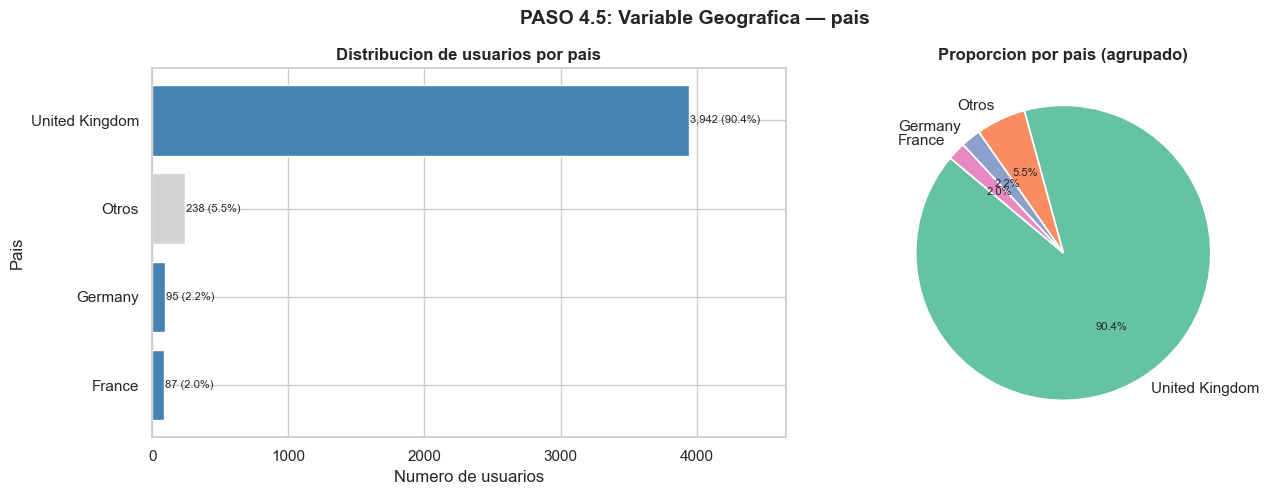

[OK] Grafico guardado en: ../../../graphics/gr_clustering/preprocesing/4.5_variable_geografica.png


In [101]:
# ── Visualización PASO 4.5 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PASO 4.5: Variable Geografica — pais', fontsize=14, fontweight='bold')

dist_plot = df_rfm['pais'].value_counts()

# [0] Barras: todos los valores de pais (incluido Otros)
ax = axes[0]
colores = ['steelblue' if p != 'Otros' else 'lightgray' for p in dist_plot.index]
bars = ax.barh(dist_plot.index[::-1], dist_plot.values[::-1], color=colores[::-1], edgecolor='white')
ax.set_title('Distribucion de usuarios por pais', fontweight='bold')
ax.set_xlabel('Numero de usuarios')
ax.set_ylabel('Pais')
for bar, v in zip(bars, dist_plot.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{v:,} ({v/len(df_rfm)*100:.1f}%)', va='center', fontsize=8)
ax.set_xlim(0, dist_plot.max() * 1.18)

# [1] Pie chart (solo los distintos grupos)
ax = axes[1]
colores_pie = plt.cm.Set2.colors
wedges, texts, autotexts = ax.pie(
    dist_plot.values,
    labels=dist_plot.index,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    colors=colores_pie[:len(dist_plot)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title('Proporcion por pais (agrupado)', fontweight='bold')

plt.tight_layout()
ruta_grafico = RUTA_GRAFICOS + '4.5_variable_geografica.png'
plt.savefig(ruta_grafico, dpi=120, bbox_inches='tight')
plt.show()
print(f'[OK] Grafico guardado en: {ruta_grafico}')

## PASO 4.6: Consolidación del Dataset Centrado en Usuarios

Todos los pasos anteriores han construido `df_rfm` de forma incremental. Este paso realiza una **revisión completa de integridad** del dataset final antes de pasar a las etapas de detección de outliers y transformación.

### Qué se verifica

| Check | Qué comprueba |
|-------|---------------|
| Dimensiones | 1 fila por usuario, columnas esperadas presentes |
| Nulos | Ninguna feature debe tener valores NaN |
| Tipos | Numérico/texto correcto por columna |
| Rangos | Ningún valor fuera de rango lógico (negativo donde no aplica) |
| Unicidad | CustomerID sin duplicados |

### Variables consolidadas (21 columnas + CustomerID)

| Grupo | Variables |
|-------|-----------|
| RFM base | `Recency`, `Frequency`, `Monetary` |
| Frecuencia temporal | `num_meses_activo`, `frecuencia_mensual`, `dias_entre_compras` |
| Valor de compra | `ticket_promedio`, `gasto_mensual` |
| Diversidad | `num_productos_unicos`, `diversidad_producto` |
| Cantidad | `cantidad_total_comprada`, `cantidad_promedio_por_compra` |
| Devoluciones | `num_cancelaciones`, `tasa_cancelacion`, `valor_devuelto`, `ratio_devolucion_monetario` |
| Temporal semanal | `dia_semana_mas_frecuente`, `compras_fin_semana`, `ratio_fin_semana` |
| Geográfica | `pais` |

> **Checkpoint exportado:** `data/interim/interim_ProyClustering/data_features_raw.csv`

In [102]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.6: CONSOLIDACIÓN DEL DATASET CENTRADO EN USUARIOS
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.6: CONSOLIDACIÓN DEL DATASET CENTRADO EN USUARIOS')
print('='*80)
print()

# ── Columnas esperadas (orden canónico) ───────────────────────────────────────
COLS_NUMERICAS = [
    'Recency', 'Frequency', 'Monetary',
    'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras',
    'ticket_promedio', 'gasto_mensual',
    'num_productos_unicos', 'diversidad_producto',
    'cantidad_total_comprada', 'cantidad_promedio_por_compra',
    'num_cancelaciones', 'tasa_cancelacion', 'valor_devuelto', 'ratio_devolucion_monetario',
    'compras_fin_semana', 'ratio_fin_semana',
]
COLS_CATEGORICAS = ['dia_semana_mas_frecuente', 'pais']
COLS_TODAS = ['CustomerID'] + COLS_NUMERICAS + COLS_CATEGORICAS

# ── Check 1: Dimensiones ──────────────────────────────────────────────────────
print('CHECK 1: Dimensiones')
print(f'  {"─"*78}')
print(f'     Filas    : {df_rfm.shape[0]:,} usuarios')
print(f'     Columnas : {df_rfm.shape[1]}')
duplicados_id = df_rfm['CustomerID'].duplicated().sum()
print(f'     CustomerID duplicados : {duplicados_id}  {"[OK]" if duplicados_id == 0 else "[ERROR] HAY DUPLICADOS"}')
print()

# ── Check 2: Columnas presentes ───────────────────────────────────────────────
print('CHECK 2: Columnas esperadas vs. presentes')
print(f'  {"─"*78}')
faltantes = [c for c in COLS_TODAS if c not in df_rfm.columns]
extras    = [c for c in df_rfm.columns if c not in COLS_TODAS]
if not faltantes:
    print(f'     [OK] Todas las columnas esperadas presentes ({len(COLS_TODAS)})')
else:
    print(f'     [ERROR] Columnas faltantes : {faltantes}')
if extras:
    print(f'     [!]  Columnas extra no esperadas : {extras}')
print()

# ── Check 3: Nulos ────────────────────────────────────────────────────────────
print('CHECK 3: Valores nulos por columna')
print(f'  {"─"*78}')
nulos = df_rfm[COLS_TODAS].isnull().sum()
nulos_total = nulos.sum()
if nulos_total == 0:
    print(f'     [OK] Sin valores nulos en ninguna columna')
else:
    print(f'     [!] Columnas con nulos:')
    for col, n in nulos[nulos > 0].items():
        print(f'          {col:<40} : {n} nulos')
print()

# ── Check 4: Tipos de dato ────────────────────────────────────────────────────
print('CHECK 4: Tipos de dato')
print(f'  {"─"*78}')
for col in COLS_NUMERICAS:
    dtype = str(df_rfm[col].dtype)
    ok = 'float' in dtype or 'int' in dtype
    estado = '[OK]' if ok else '[!] INESPERADO'
    print(f'     {col:<40} : {dtype:<12}  {estado}')
for col in COLS_CATEGORICAS:
    dtype = str(df_rfm[col].dtype)
    ok = dtype == 'object'
    estado = '[OK]' if ok else '[!] INESPERADO'
    print(f'     {col:<40} : {dtype:<12}  {estado}')
print()

# ── Check 5: Rangos lógicos (variables no negativas) ─────────────────────────
print('CHECK 5: Rangos logicos (minimos de variables no-negativas)')
print(f'  {"─"*78}')
COLS_NO_NEGATIVAS = [
    'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual',
    'dias_entre_compras', 'ticket_promedio', 'gasto_mensual', 'num_productos_unicos',
    'diversidad_producto', 'cantidad_total_comprada', 'cantidad_promedio_por_compra',
    'num_cancelaciones', 'tasa_cancelacion', 'valor_devuelto', 'ratio_devolucion_monetario',
    'compras_fin_semana', 'ratio_fin_semana',
]
errores_rango = []
for col in COLS_NO_NEGATIVAS:
    minimo = df_rfm[col].min()
    ok = minimo >= 0
    if not ok:
        errores_rango.append(col)
    estado = '[OK]' if ok else f'[ERROR] min={minimo}'
    print(f'     {col:<40} : min={minimo:>12.4f}  {estado}')
if not errores_rango:
    print()
    print(f'     [OK] Ninguna variable no-negativa tiene valores negativos')
print()

# ── Resumen estadístico de todas las numéricas ────────────────────────────────
print('RESUMEN ESTADÍSTICO (variables numericas):')
print(f'  {"─"*78}')
stats = df_rfm[COLS_NUMERICAS].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats.columns = ['Media', 'Std', 'Min', 'P25', 'Mediana', 'P75', 'Max']
print(stats.to_string())
print()

# ── Distribución de variables categóricas ─────────────────────────────────────
print('DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS:')
print(f'  {"─"*78}')
print(f'\n  dia_semana_mas_frecuente:')
DIAS_ORDEN_LOCAL = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Unknown']
for dia in DIAS_ORDEN_LOCAL:
    n = (df_rfm['dia_semana_mas_frecuente'] == dia).sum()
    if n > 0:
        print(f'     {dia:<12} : {n:>5,} ({n/len(df_rfm)*100:.1f}%)')
print(f'\n  pais:')
for p, n in df_rfm['pais'].value_counts().items():
    print(f'     {p:<35} : {n:>5,} ({n/len(df_rfm)*100:.1f}%)')
print()

# ── Export checkpoint ─────────────────────────────────────────────────────────
print('EXPORTANDO CHECKPOINT: data_features_raw.csv')
print(f'  {"─"*78}')

import os
RUTA_INTERIM_CLUSTERING = '../../../data/interim/interim_ProyClustering/'
os.makedirs(RUTA_INTERIM_CLUSTERING, exist_ok=True)

ruta_export = RUTA_INTERIM_CLUSTERING + 'data_features_raw.csv'
df_rfm[COLS_TODAS].to_csv(ruta_export, index=False)

print(f'     [OK] Exportado a : {ruta_export}')
print(f'     Filas exportadas : {df_rfm.shape[0]:,}')
print(f'     Cols exportadas  : {len(COLS_TODAS)} ({len(COLS_NUMERICAS)} numericas + {len(COLS_CATEGORICAS)} categoricas + CustomerID)')
print()
print('='*80)
print('  PASO 4 COMPLETO — Dataset de usuarios listo para PASO 5 (Outliers)')
print('='*80)

  PASO 4.6: CONSOLIDACIÓN DEL DATASET CENTRADO EN USUARIOS

CHECK 1: Dimensiones
  ──────────────────────────────────────────────────────────────────────────────
     Filas    : 4,362 usuarios
     Columnas : 21
     CustomerID duplicados : 0  [OK]

CHECK 2: Columnas esperadas vs. presentes
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Todas las columnas esperadas presentes (21)

CHECK 3: Valores nulos por columna
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Sin valores nulos en ninguna columna

CHECK 4: Tipos de dato
  ──────────────────────────────────────────────────────────────────────────────
     Recency                                  : int64         [OK]
     Frequency                                : int64         [OK]
     Monetary                                 : float64       [OK]
     num_meses_activo                         : int64         [OK]
     frecuencia_mensual             

## PASO 5: Limpieza del Dataset Centrado en Usuarios

El dataset de usuarios contiene features con distribuciones muy sesgadas (Monetary, valor_devuelto, cantidad_total_comprada…). Antes de aplicar cualquier transformación es necesario **entender la distribución real** de cada variable para tomar decisiones informadas sobre el tratamiento de outliers.

### PASO 5.1: Análisis Exploratorio de Features

| Sub-paso | Contenido |
|----------|-----------|
| 5.1.A | Estadísticas descriptivas: `describe()` + ratio rango + skewness por feature |
| 5.1.B | Histogramas de todas las features numéricas (distribución real) |
| 5.1.C | Boxplots de todas las features numéricas (outliers visuales) |

> Las features numéricas analizadas son las **18 variables** de `COLS_NUMERICAS` (sin CustomerID ni categóricas).

In [103]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 5.1.A: ESTADÍSTICAS DESCRIPTIVAS DE FEATURES
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 5.1.A: ESTADÍSTICAS DESCRIPTIVAS DE FEATURES NUMÉRICAS')
print('='*80)
print()

df_num = df_rfm[COLS_NUMERICAS].copy()

# ── Tabla resumen ampliada ────────────────────────────────────────────────────
stats_51 = df_num.describe().T
stats_51['skewness']   = df_num.skew()
stats_51['kurtosis']   = df_num.kurt()
stats_51['rango']      = stats_51['max'] - stats_51['min']
stats_51['IQR']        = stats_51['75%'] - stats_51['25%']
# Ratio rango: cuántas veces es el máximo mayor que la mediana (sensible a outliers)
stats_51['ratio_max_median'] = stats_51.apply(
    lambda r: r['max'] / r['50%'] if r['50%'] > 0 else float('inf'), axis=1
)
# Porcentaje de ceros
stats_51['pct_ceros'] = (df_num == 0).mean() * 100

print('Tabla de estadísticas (8 columnas clave):')
print(f'  {"─"*78}')
cols_mostrar = ['mean', '50%', 'std', 'min', 'max', 'skewness', 'ratio_max_median', 'pct_ceros']
print(stats_51[cols_mostrar].round(3).to_string())
print()

# ── Clasificación por severidad de sesgo ─────────────────────────────────────
print('Clasificación por skewness (sesgo):')
print(f'  {"─"*78}')
print(f'  {"Feature":<40} {"Skewness":>10}  Severidad')
print(f'  {"─"*78}')

for col in COLS_NUMERICAS:
    sk = df_num[col].skew()
    if abs(sk) < 1:
        nivel = 'bajo      (simetrica o leve)'
    elif abs(sk) < 2:
        nivel = '[!] moderado'
    else:
        nivel = '[!!] ALTO — necesita transformacion'
    print(f'  {col:<40} {sk:>10.3f}  {nivel}')
print()

# ── Features con ratio_max_median extremo ────────────────────────────────────
print('Features con ratio max/mediana > 10 (candidatas a outliers):')
print(f'  {"─"*78}')
extremas = stats_51[stats_51['ratio_max_median'] > 10]['ratio_max_median'].sort_values(ascending=False)
if len(extremas) == 0:
    print('     [OK] Ninguna feature supera ratio 10x')
else:
    for col, ratio in extremas.items():
        print(f'     {col:<40} : ratio max/mediana = {ratio:>8.1f}x')
print()

  PASO 5.1.A: ESTADÍSTICAS DESCRIPTIVAS DE FEATURES NUMÉRICAS

Tabla de estadísticas (8 columnas clave):
  ──────────────────────────────────────────────────────────────────────────────
                                mean    50%     std  min       max  skewness  ratio_max_median  pct_ceros
Recency                        92.17  50.00  100.97 1.00    374.00      1.25              7.48       0.00
Frequency                       4.22   2.00    7.62 0.00    206.00     11.96            103.00       0.64
Monetary                     1736.02 639.27 6264.09 0.00 223521.60     19.32            349.65       0.64
num_meses_activo                2.99   2.00    2.63 0.00     13.00      1.77              6.50       0.64
frecuencia_mensual              1.21   1.00    0.76 0.00     34.00     22.66             34.00       0.64
dias_entre_compras             47.26  27.70   63.15 0.00    365.00      2.12             13.18      36.52
ticket_promedio               349.02 276.06  365.59 0.00   9029.26      

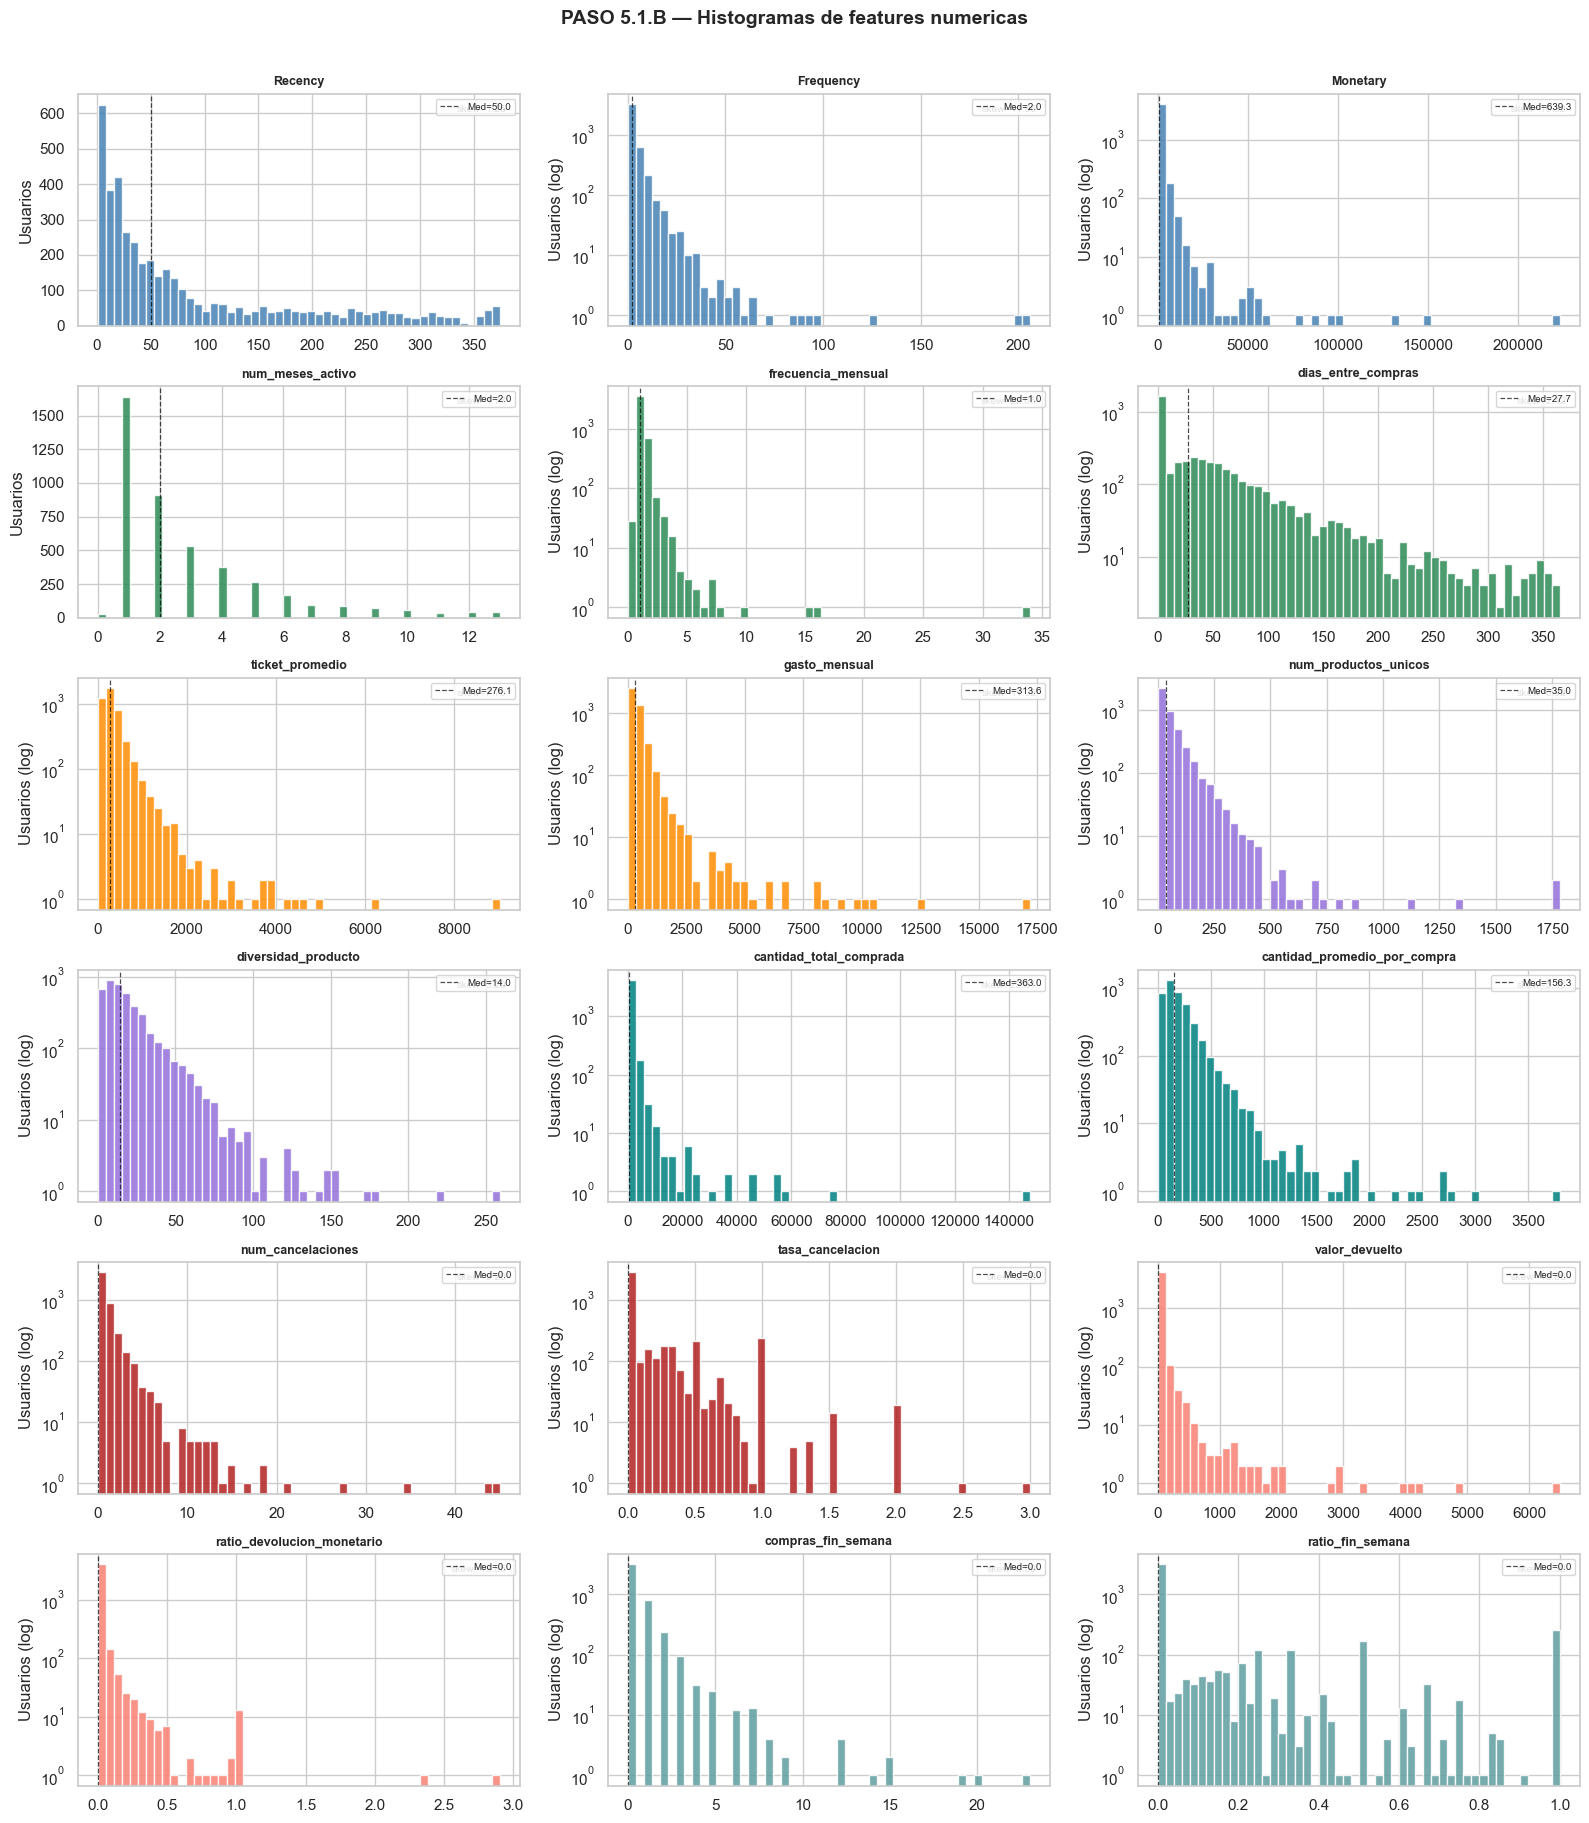

[OK] Grafico guardado en: ../../../graphics/gr_clustering/preprocesing/5.1.B_histogramas_features.png


In [104]:
# ── 5.1.B: Histogramas de todas las features numéricas ───────────────────────
NCOLS = 3
NROWS = 6   # 18 features / 3 cols = 6 filas exactas

COLORES_GRUPOS = {
    'Recency':                     'steelblue',
    'Frequency':                   'steelblue',
    'Monetary':                    'steelblue',
    'num_meses_activo':            'seagreen',
    'frecuencia_mensual':          'seagreen',
    'dias_entre_compras':          'seagreen',
    'ticket_promedio':             'darkorange',
    'gasto_mensual':               'darkorange',
    'num_productos_unicos':        'mediumpurple',
    'diversidad_producto':         'mediumpurple',
    'cantidad_total_comprada':     'teal',
    'cantidad_promedio_por_compra':'teal',
    'num_cancelaciones':           'firebrick',
    'tasa_cancelacion':            'firebrick',
    'valor_devuelto':              'salmon',
    'ratio_devolucion_monetario':  'salmon',
    'compras_fin_semana':          'cadetblue',
    'ratio_fin_semana':            'cadetblue',
}

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, NROWS * 3))
fig.suptitle('PASO 5.1.B — Histogramas de features numericas', fontsize=14, fontweight='bold', y=1.01)

for idx, col in enumerate(COLS_NUMERICAS):
    ax = axes[idx // NCOLS][idx % NCOLS]
    data = df_num[col].dropna()
    color = COLORES_GRUPOS.get(col, 'steelblue')

    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Usuarios')

    sk = data.skew()
    ax.text(0.97, 0.95, f'skew={sk:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=7.5, color='dimgray')

    # Log Y si la distribución es muy sesgada
    if abs(sk) > 2:
        ax.set_yscale('log')
        ax.set_ylabel('Usuarios (log)')

    med = data.median()
    ax.axvline(med, color='black', linestyle='--', linewidth=0.9, alpha=0.7, label=f'Med={med:.1f}')
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
ruta_grafico = RUTA_GRAFICOS + '5.1.B_histogramas_features.png'
plt.savefig(ruta_grafico, dpi=110, bbox_inches='tight')
plt.show()
print(f'[OK] Grafico guardado en: {ruta_grafico}')

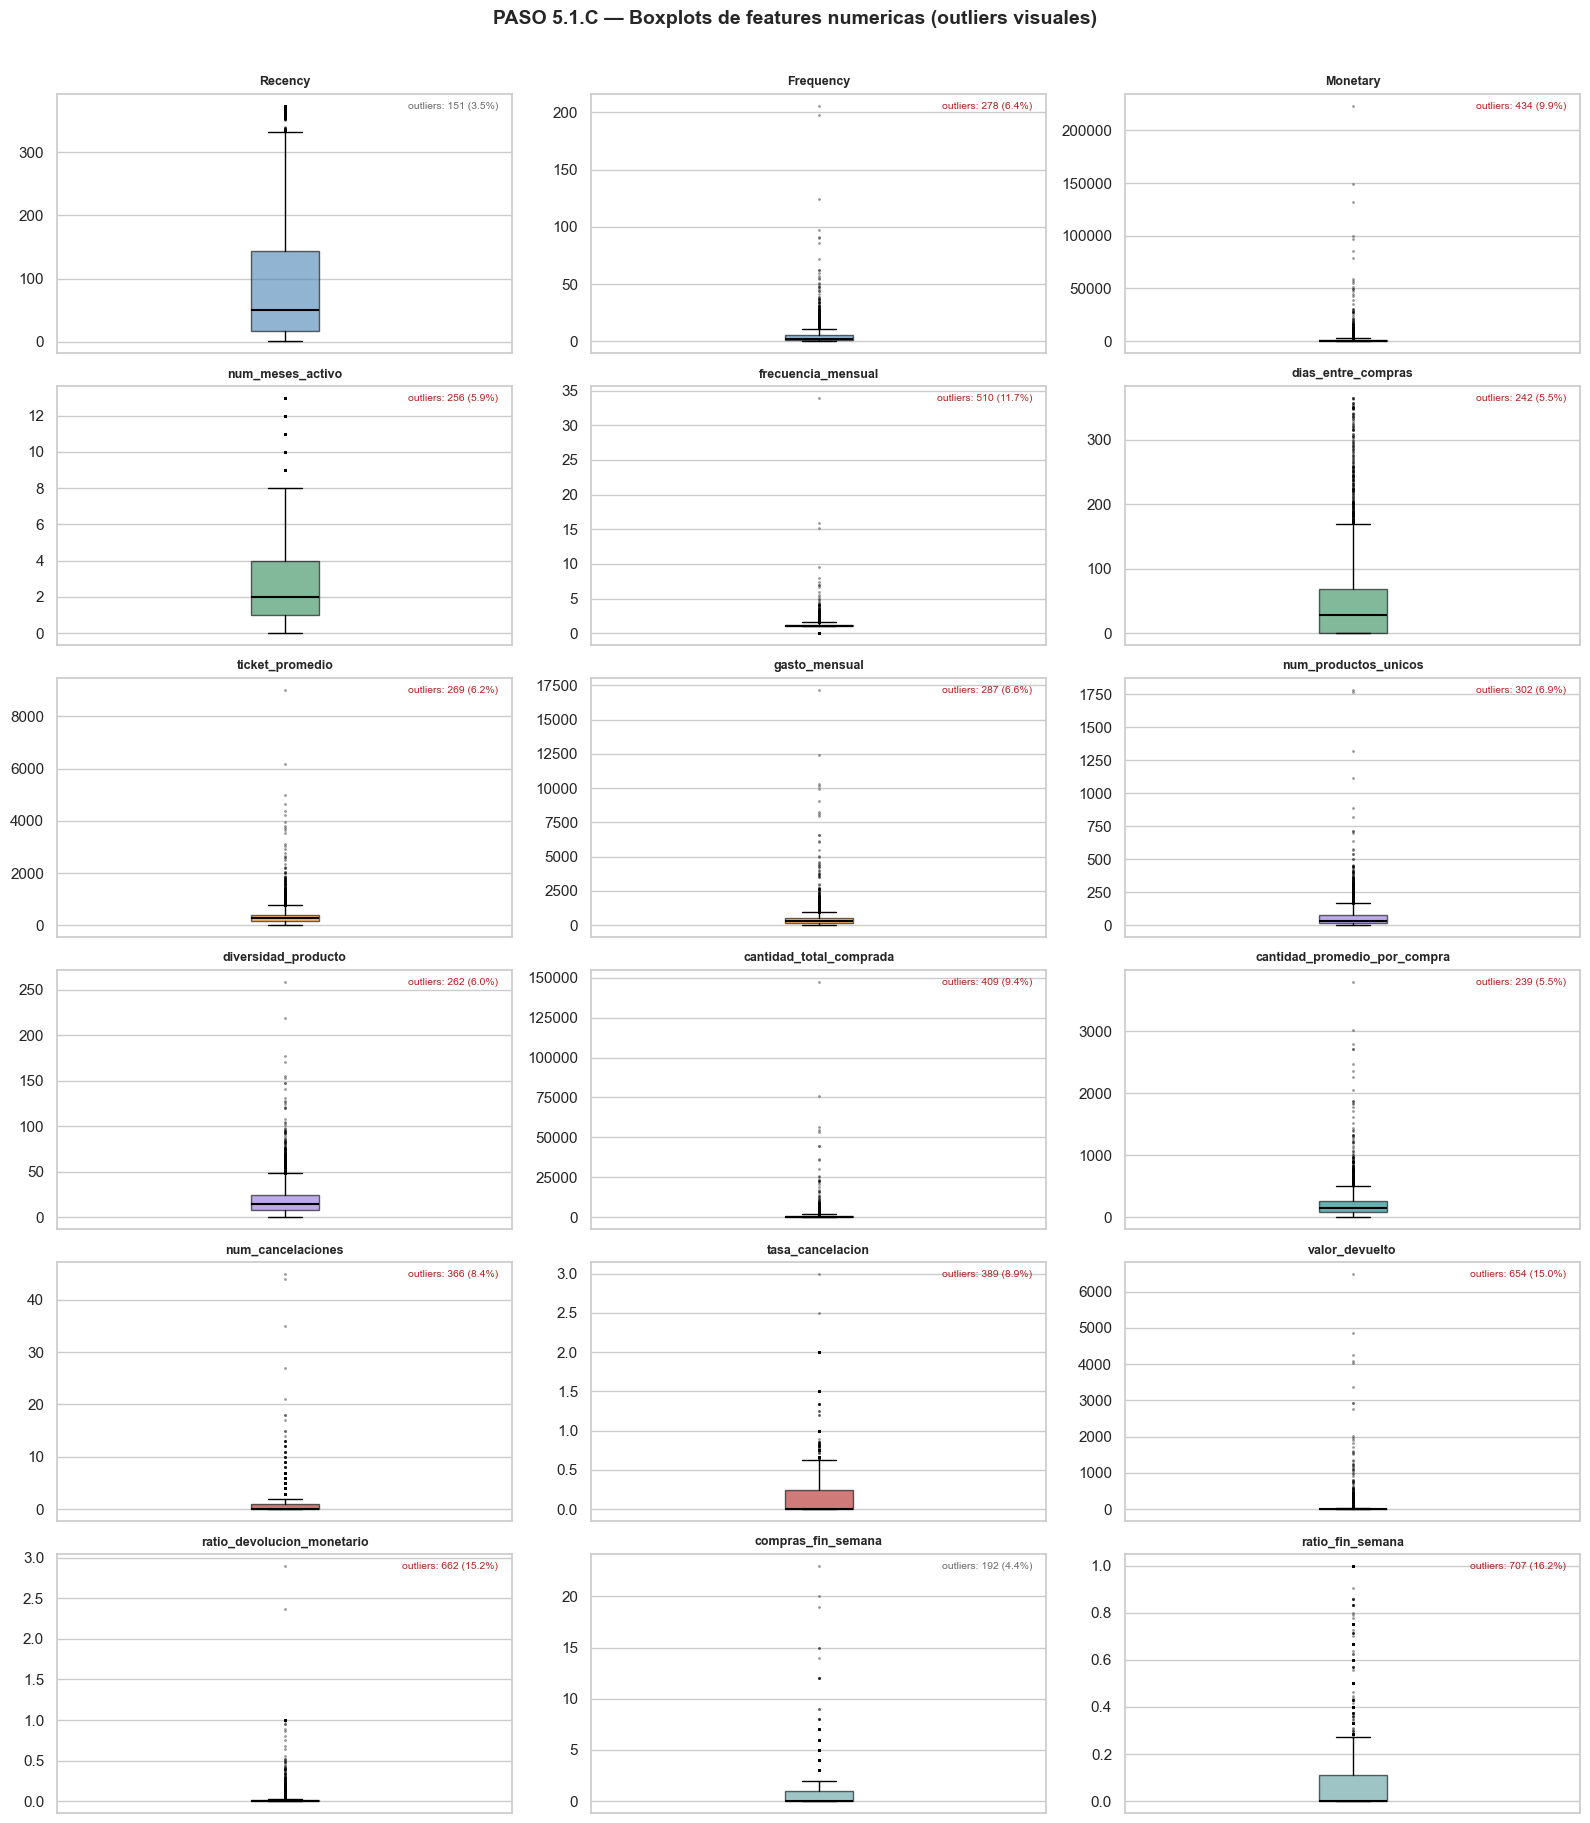

[OK] Grafico guardado en: ../../../graphics/gr_clustering/preprocesing/5.1.C_boxplots_features.png


In [105]:
# ── 5.1.C: Boxplots de todas las features numéricas ──────────────────────────
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, NROWS * 3))
fig.suptitle('PASO 5.1.C — Boxplots de features numericas (outliers visuales)', fontsize=14, fontweight='bold', y=1.01)

for idx, col in enumerate(COLS_NUMERICAS):
    ax = axes[idx // NCOLS][idx % NCOLS]
    data = df_num[col].dropna()
    color = COLORES_GRUPOS.get(col, 'steelblue')

    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='.', markersize=2, alpha=0.4, color='dimgray'),
                    whiskerprops=dict(linewidth=1),
                    capprops=dict(linewidth=1))

    # Contar outliers (puntos fuera de los whiskers)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct_out = n_outliers / len(data) * 100

    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.text(0.97, 0.97, f'outliers: {n_outliers} ({pct_out:.1f}%)',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
            color='firebrick' if pct_out > 5 else 'dimgray')

plt.tight_layout()
ruta_grafico = RUTA_GRAFICOS + '5.1.C_boxplots_features.png'
plt.savefig(ruta_grafico, dpi=110, bbox_inches='tight')
plt.show()
print(f'[OK] Grafico guardado en: {ruta_grafico}')

## PASO 5.2: Detección y Eliminación de Outliers

### Decisión: Estrategia combinada (capping + Isolation Forest)

El análisis de 5.1 revela distribuciones muy sesgadas con valores extremos tanto univariantes (un usuario con Monetary 30x la mediana) como multivariantes (combinaciones anómalas de varias features). Un único umbral IQR no es suficiente para el segundo caso.

| Paso | Técnica | Justificación |
|------|---------|---------------|
| 5.2.A | Capping suave al p99 | Reduce extremos en features con skew > 2 sin eliminar usuarios |
| 5.2.B | Isolation Forest `contamination=0.05` | Detecta outliers **multivariantes** que el capping no captura |
| 5.2.C | Eliminación del 5% más anómalo | Cumple con el requisito del proyecto (5-10% máximo) |

### Configuración de Isolation Forest

| Parámetro | Valor | Razón |
|-----------|-------|-------|
| `contamination` | 0.05 | 5% esperado — ~218 usuarios de 4,362 |
| `n_estimators` | 200 | Más árboles → estimación más estable |
| `random_state` | 42 | Reproducibilidad |
| Input | 18 features numéricas (post-capping) escaladas con `RobustScaler` | RobustScaler robusto frente a sesgos residuales |

> Nota: las features categóricas (`dia_semana_mas_frecuente`, `pais`) no se usan en IF — solo las 18 numéricas.

In [106]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 5.2.A: CAPPING SUAVE AL P99
#   PASO 5.2.B: ISOLATION FOREST — DETECCIÓN DE OUTLIERS
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import RobustScaler
import joblib

print('='*80)
print('  PASO 5.2: DETECCIÓN DE OUTLIERS (CAPPING P99 + ISOLATION FOREST)')
print('='*80)
print()

# ── 5.2.A: Capping suave al p99 sobre features con skew > 2 ─────────────────
print('5.2.A — Capping suave al p99 (features con skewness > 2)')
print(f'  {"─"*78}')

df_clean = df_rfm[COLS_TODAS].copy()

FEATURES_CAPPING = [col for col in COLS_NUMERICAS if abs(df_num[col].skew()) > 2]
print(f'     Features candidatas al capping ({len(FEATURES_CAPPING)}):')

p99 = df_clean[FEATURES_CAPPING].quantile(0.99)
for col in FEATURES_CAPPING:
    antes = df_clean[col].max()
    df_clean[col] = df_clean[col].clip(upper=p99[col])
    despues = df_clean[col].max()
    recortados = (df_rfm[col] > p99[col]).sum()
    print(f'       {col:<40} p99={p99[col]:>10.2f}  max_antes={antes:>12.2f}  recortados={recortados}')

print()
print(f'     [OK] Capping aplicado. Usuarios: {len(df_clean):,} (sin eliminaciones)')
print()

# ── 5.2.B: Isolation Forest ──────────────────────────────────────────────────
print('5.2.B — Entrenando Isolation Forest (contamination=0.05)...')
print(f'  {"─"*78}')

X_num = df_clean[COLS_NUMERICAS].values

scaler_if = RobustScaler()
X_scaled  = scaler_if.fit_transform(X_num)

CONTAMINATION = 0.05
if_model = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1
)
if_model.fit(X_scaled)

df_clean['outlier_if']    = if_model.predict(X_scaled)   # -1=outlier, 1=inlier
df_clean['outlier_score'] = if_model.score_samples(X_scaled)  # más negativo = más anómalo

n_outliers_if = (df_clean['outlier_if'] == -1).sum()
n_inliers_if  = (df_clean['outlier_if'] ==  1).sum()
pct_outliers  = n_outliers_if / len(df_clean) * 100

print(f'     [OK] Modelo entrenado')
print(f'     Usuarios marcados como outliers : {n_outliers_if:>6,} ({pct_outliers:.1f}%)')
print(f'     Usuarios normales (inliers)     : {n_inliers_if:>6,} ({100-pct_outliers:.1f}%)')
print()

# ── Perfil de los outliers detectados ────────────────────────────────────────
print('Perfil comparativo: OUTLIERS vs. NORMALES (medias de features):')
print(f'  {"─"*78}')

df_outliers_view = df_clean[df_clean['outlier_if'] == -1]
df_inliers_view  = df_clean[df_clean['outlier_if'] ==  1]

comparacion = pd.DataFrame({
    'Media_outliers': df_outliers_view[COLS_NUMERICAS].mean(),
    'Media_normales': df_inliers_view[COLS_NUMERICAS].mean(),
})
comparacion['Ratio'] = comparacion.apply(
    lambda r: r['Media_outliers'] / r['Media_normales']
    if r['Media_normales'] != 0 else float('inf'), axis=1
)
comparacion = comparacion.sort_values('Ratio', ascending=False)

print(f'  {"Feature":<40} {"Outliers":>12} {"Normales":>12} {"Ratio":>8}')
print(f'  {"─"*78}')
for col, row in comparacion.iterrows():
    flag = '  [!!]' if row['Ratio'] > 3 or row['Ratio'] < 0.33 else ''
    print(f'  {col:<40} {row["Media_outliers"]:>12.2f} {row["Media_normales"]:>12.2f} {row["Ratio"]:>8.2f}x{flag}')
print()

# ── Top 10 outliers más extremos ─────────────────────────────────────────────
print('Top 10 usuarios más anómalos (menor outlier_score):')
print(f'  {"─"*78}')
top10 = (
    df_clean[df_clean['outlier_if'] == -1]
    .nsmallest(10, 'outlier_score')[['CustomerID', 'outlier_score', 'Recency', 'Frequency', 'Monetary', 'valor_devuelto', 'num_cancelaciones']]
)
print(top10.to_string(index=False))
print()

  PASO 5.2: DETECCIÓN DE OUTLIERS (CAPPING P99 + ISOLATION FOREST)

5.2.A — Capping suave al p99 (features con skewness > 2)
  ──────────────────────────────────────────────────────────────────────────────
     Features candidatas al capping (16):
       Frequency                                p99=     30.00  max_antes=      206.00  recortados=42
       Monetary                                 p99=  15768.94  max_antes=   223521.60  recortados=44
       frecuencia_mensual                       p99=      3.00  max_antes=       34.00  recortados=43
       dias_entre_compras                       p99=    305.39  max_antes=      365.00  recortados=44
       ticket_promedio                          p99=   1651.51  max_antes=     9029.26  recortados=44
       gasto_mensual                            p99=   2404.78  max_antes=    17193.97  recortados=44
       num_productos_unicos                     p99=    353.39  max_antes=     1785.00  recortados=44
       diversidad_producto            

In [107]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 5.2.C: ELIMINACIÓN DE OUTLIERS + ESTADO FINAL + EXPORT
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 5.2.C: ELIMINACIÓN DE OUTLIERS')
print('='*80)
print()

# ── Eliminar usuarios marcados como outliers ──────────────────────────────────
df_rfm_clean = (
    df_clean[df_clean['outlier_if'] == 1]
    [COLS_TODAS]           # solo columnas originales (sin outlier_if, outlier_score)
    .reset_index(drop=True)
)

n_original = len(df_rfm)
n_final    = len(df_rfm_clean)
n_eliminados = n_original - n_final

print(f'     Usuarios antes (originales) : {n_original:>6,}')
print(f'     Usuarios eliminados         : {n_eliminados:>6,} ({n_eliminados/n_original*100:.1f}%)')
print(f'     Usuarios despues (limpios)  : {n_final:>6,} ({n_final/n_original*100:.1f}%)')
print()

# ── Verificación de integridad post-eliminación ───────────────────────────────
print('Verificacion post-eliminacion:')
print(f'  {"─"*78}')
nulos_post = df_rfm_clean[COLS_NUMERICAS].isnull().sum().sum()
duplicados_post = df_rfm_clean['CustomerID'].duplicated().sum()
print(f'     Nulos en features numericas : {nulos_post}  {"[OK]" if nulos_post == 0 else "[ERROR]"}')
print(f'     CustomerID duplicados       : {duplicados_post}  {"[OK]" if duplicados_post == 0 else "[ERROR]"}')
print(f'     Columnas                    : {df_rfm_clean.shape[1]}')
print()

# ── Resumen estadístico post-limpieza (Monetary, Frequency, Recency) ──────────
print('Comparacion estadistica antes/despues (features clave):')
print(f'  {"─"*78}')
for col in ['Recency', 'Frequency', 'Monetary', 'valor_devuelto', 'cantidad_total_comprada']:
    antes_max  = df_rfm[col].max()
    despues_max = df_rfm_clean[col].max()
    antes_med  = df_rfm[col].median()
    despues_med = df_rfm_clean[col].median()
    print(f'  {col:<40}')
    print(f'       max:    antes={antes_max:>12.2f}  despues={despues_max:>12.2f}')
    print(f'       median: antes={antes_med:>12.2f}  despues={despues_med:>12.2f}')
print()

# ── Guardar modelo IF y scaler ────────────────────────────────────────────────
print('Guardando modelo Isolation Forest y RobustScaler...')
print(f'  {"─"*78}')
import os
os.makedirs(RUTA_MODELS, exist_ok=True)
joblib.dump(if_model,   RUTA_MODELS + 'isolation_forest.pkl')
joblib.dump(scaler_if,  RUTA_MODELS + 'scaler_robust_if.pkl')
print(f'     [OK] isolation_forest.pkl  guardado en {RUTA_MODELS}')
print(f'     [OK] scaler_robust_if.pkl  guardado en {RUTA_MODELS}')
print()

# ── Export checkpoint limpio ──────────────────────────────────────────────────
print('Exportando checkpoint: data_features_clean.csv')
print(f'  {"─"*78}')
ruta_clean = RUTA_INTERIM_CLUSTERING + 'data_features_clean.csv'
df_rfm_clean.to_csv(ruta_clean, index=False)
print(f'     [OK] Exportado a: {ruta_clean}')
print(f'     Filas : {df_rfm_clean.shape[0]:,}')
print(f'     Cols  : {df_rfm_clean.shape[1]}')
print()
print('='*80)
print('  PASO 5.2 COMPLETO — Dataset sin outliers listo para PASO 6 (Scaling)')
print('='*80)

  PASO 5.2.C: ELIMINACIÓN DE OUTLIERS

     Usuarios antes (originales) :  4,362
     Usuarios eliminados         :    219 (5.0%)
     Usuarios despues (limpios)  :  4,143 (95.0%)

Verificacion post-eliminacion:
  ──────────────────────────────────────────────────────────────────────────────
     Nulos en features numericas : 0  [OK]
     CustomerID duplicados       : 0  [OK]
     Columnas                    : 21

Comparacion estadistica antes/despues (features clave):
  ──────────────────────────────────────────────────────────────────────────────
  Recency                                 
       max:    antes=      374.00  despues=      374.00
       median: antes=       50.00  despues=       52.00
  Frequency                               
       max:    antes=      206.00  despues=       30.00
       median: antes=        2.00  despues=        2.00
  Monetary                                
       max:    antes=   223521.60  despues=    10264.45
       median: antes=      639.27  d

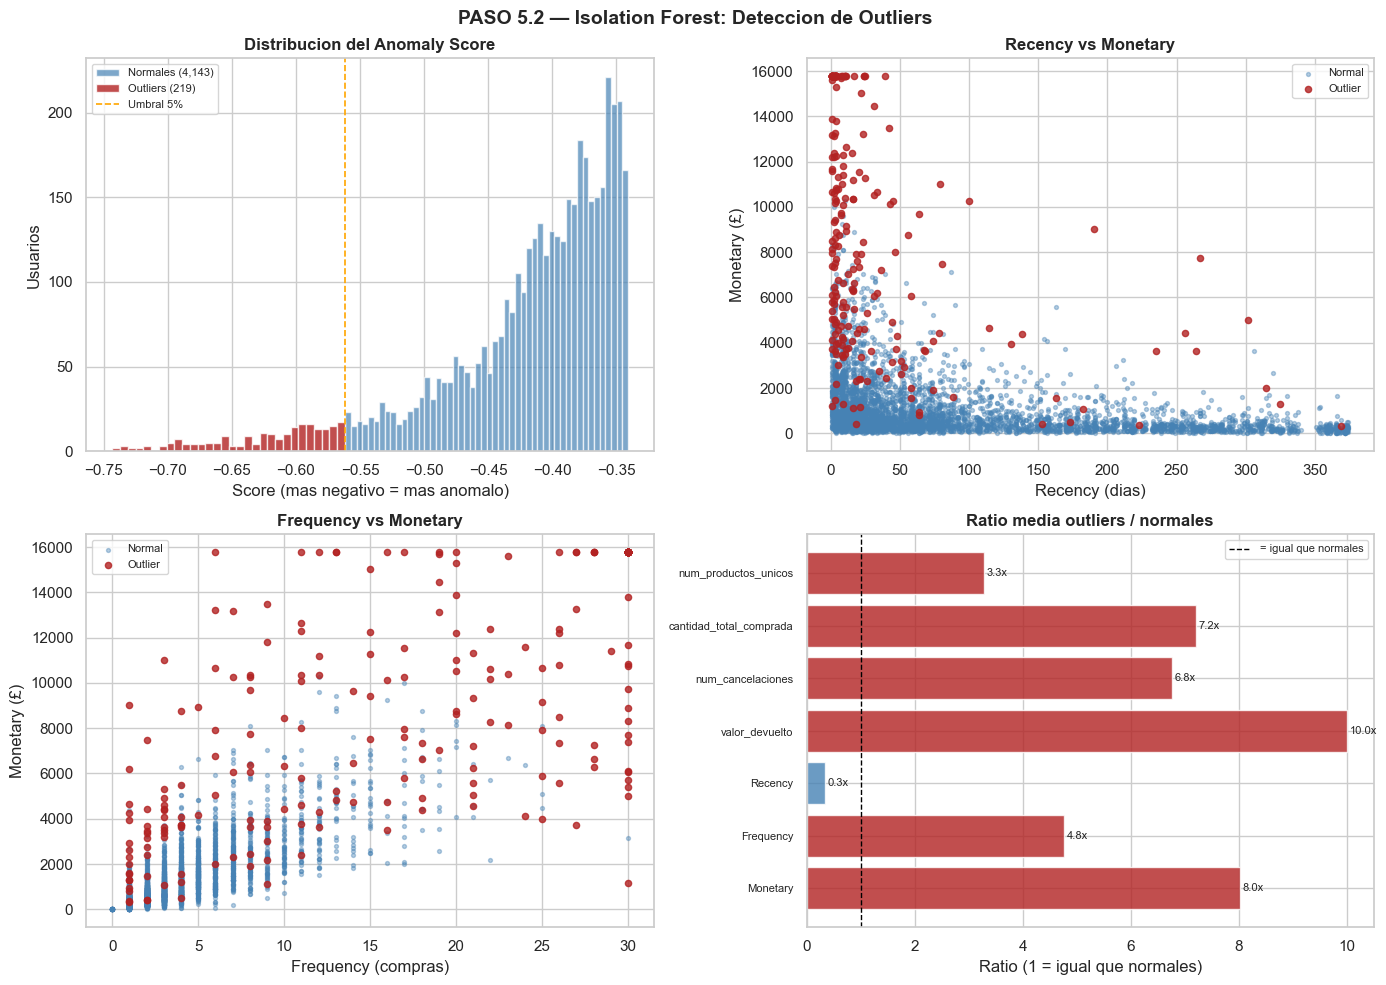

[OK] Grafico guardado en: ../../../graphics/gr_clustering/preprocesing/5.2_isolation_forest_outliers.png


In [108]:
# ── Visualización PASO 5.2 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PASO 5.2 — Isolation Forest: Deteccion de Outliers', fontsize=14, fontweight='bold')

colores_map = df_clean['outlier_if'].map({1: 'steelblue', -1: 'firebrick'})

# [0,0] Distribución del anomaly score
ax = axes[0, 0]
scores_inliers  = df_clean.loc[df_clean['outlier_if'] ==  1, 'outlier_score']
scores_outliers = df_clean.loc[df_clean['outlier_if'] == -1, 'outlier_score']
ax.hist(scores_inliers,  bins=50, color='steelblue', alpha=0.7, label=f'Normales ({len(scores_inliers):,})')
ax.hist(scores_outliers, bins=30, color='firebrick',  alpha=0.8, label=f'Outliers ({len(scores_outliers):,})')
ax.set_title('Distribucion del Anomaly Score', fontweight='bold')
ax.set_xlabel('Score (mas negativo = mas anomalo)')
ax.set_ylabel('Usuarios')
ax.legend(fontsize=9)
ax.axvline(df_clean['outlier_score'].quantile(CONTAMINATION), color='orange',
           linestyle='--', linewidth=1.2, label='Umbral 5%')
ax.legend(fontsize=8)

# [0,1] Scatter Recency vs Monetary — coloreado por outlier
ax = axes[0, 1]
ax.scatter(df_clean.loc[df_clean['outlier_if']==1, 'Recency'],
           df_clean.loc[df_clean['outlier_if']==1, 'Monetary'],
           s=8, alpha=0.4, color='steelblue', label='Normal')
ax.scatter(df_clean.loc[df_clean['outlier_if']==-1, 'Recency'],
           df_clean.loc[df_clean['outlier_if']==-1, 'Monetary'],
           s=20, alpha=0.8, color='firebrick', label='Outlier', zorder=5)
ax.set_title('Recency vs Monetary', fontweight='bold')
ax.set_xlabel('Recency (dias)')
ax.set_ylabel('Monetary (£)')
ax.legend(fontsize=8)

# [1,0] Scatter Frequency vs Monetary
ax = axes[1, 0]
ax.scatter(df_clean.loc[df_clean['outlier_if']==1, 'Frequency'],
           df_clean.loc[df_clean['outlier_if']==1, 'Monetary'],
           s=8, alpha=0.4, color='steelblue', label='Normal')
ax.scatter(df_clean.loc[df_clean['outlier_if']==-1, 'Frequency'],
           df_clean.loc[df_clean['outlier_if']==-1, 'Monetary'],
           s=20, alpha=0.8, color='firebrick', label='Outlier', zorder=5)
ax.set_title('Frequency vs Monetary', fontweight='bold')
ax.set_xlabel('Frequency (compras)')
ax.set_ylabel('Monetary (£)')
ax.legend(fontsize=8)

# [1,1] Comparación de medias: outliers vs normales (barras horizontales)
ax = axes[1, 1]
features_plot = ['Monetary', 'Frequency', 'Recency', 'valor_devuelto', 'num_cancelaciones',
                 'cantidad_total_comprada', 'num_productos_unicos']
medias_out = df_outliers_view[features_plot].mean()
medias_nor = df_inliers_view[features_plot].mean()
# Normalizar al máximo de cada feature para comparación relativa
ratios = (medias_out / medias_nor.replace(0, 1)).clip(0, 10)
y_pos  = range(len(features_plot))
colores_bar = ['firebrick' if r > 2 else 'steelblue' for r in ratios]
bars = ax.barh(list(y_pos), ratios.values, color=colores_bar, edgecolor='white', alpha=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(features_plot, fontsize=8)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='= igual que normales')
ax.set_title('Ratio media outliers / normales', fontweight='bold')
ax.set_xlabel('Ratio (1 = igual que normales)')
ax.legend(fontsize=8)
for bar, v in zip(bars, ratios.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}x', va='center', fontsize=8)

plt.tight_layout()
ruta_grafico = RUTA_GRAFICOS + '5.2_isolation_forest_outliers.png'
plt.savefig(ruta_grafico, dpi=120, bbox_inches='tight')
plt.show()
print(f'[OK] Grafico guardado en: {ruta_grafico}')

## PASO 5.4: Verificación Post-Limpieza

Con los outliers eliminados, se compara el dataset **antes** (`df_rfm`, 4,362 usuarios) y **después** (`df_rfm_clean`) para confirmar que:

1. La eliminación es ≤ 10% del total
2. Las distribuciones mejoran (reducción de colas extremas)
3. Las estadísticas centrales (mediana) no cambian significativamente — se conserva la estructura del dataset

> `df_rfm` = dataset original (con capping aplicado en las features con skew > 2)  
> `df_rfm_clean` = dataset limpio (tras eliminar outliers detectados por Isolation Forest)

In [109]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 5.4: VERIFICACIÓN POST-LIMPIEZA
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 5.4: VERIFICACIÓN POST-LIMPIEZA')
print('='*80)
print()

# ── Confirmación: % eliminado ≤ 10% ─────────────────────────────────────────
n_antes  = len(df_rfm)
n_despues = len(df_rfm_clean)
n_elim   = n_antes - n_despues
pct_elim = n_elim / n_antes * 100

estado_req = '[OK]' if pct_elim <= 10 else '[ERROR] SUPERA EL 10%'
print(f'Requisito del proyecto: eliminar como maximo el 10% de usuarios')
print(f'  {"─"*78}')
print(f'     Usuarios originales  : {n_antes:>6,}')
print(f'     Usuarios eliminados  : {n_elim:>6,} ({pct_elim:.2f}%)')
print(f'     Usuarios finales     : {n_despues:>6,}')
print(f'     {estado_req} — porcentaje eliminado: {pct_elim:.2f}%')
print()

# ── Tabla estadísticas antes/después para features clave ─────────────────────
FEATURES_VERIFICAR = [
    'Recency', 'Frequency', 'Monetary',
    'ticket_promedio', 'num_productos_unicos',
    'valor_devuelto', 'tasa_cancelacion',
    'cantidad_total_comprada', 'dias_entre_compras',
]

print('Estadísticas comparativas antes/después (features clave):')
print(f'  {"─"*78}')
print(f'  {"Feature":<35} {"Antes_med":>10} {"Desp_med":>10} {"Antes_max":>12} {"Desp_max":>12} {"Antes_std":>10} {"Desp_std":>10}')
print(f'  {"─"*78}')

for col in FEATURES_VERIFICAR:
    a_med = df_rfm[col].median()
    d_med = df_rfm_clean[col].median()
    a_max = df_rfm[col].max()
    d_max = df_rfm_clean[col].max()
    a_std = df_rfm[col].std()
    d_std = df_rfm_clean[col].std()
    cambio_med = (d_med - a_med) / a_med * 100 if a_med != 0 else 0
    flag = f'  [!] med cambio {cambio_med:+.1f}%' if abs(cambio_med) > 10 else ''
    print(f'  {col:<35} {a_med:>10.2f} {d_med:>10.2f} {a_max:>12.2f} {d_max:>12.2f} {a_std:>10.2f} {d_std:>10.2f}{flag}')
print()

  PASO 5.4: VERIFICACIÓN POST-LIMPIEZA

Requisito del proyecto: eliminar como maximo el 10% de usuarios
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios originales  :  4,362
     Usuarios eliminados  :    219 (5.02%)
     Usuarios finales     :  4,143
     [OK] — porcentaje eliminado: 5.02%

Estadísticas comparativas antes/después (features clave):
  ──────────────────────────────────────────────────────────────────────────────
  Feature                              Antes_med   Desp_med    Antes_max     Desp_max  Antes_std   Desp_std
  ──────────────────────────────────────────────────────────────────────────────
  Recency                                  50.00      52.00       374.00       374.00     100.97     101.63
  Frequency                                 2.00       2.00       206.00        30.00       7.62       3.31
  Monetary                                639.27     594.37    223521.60     10264.45    6264.09    1283.78
  ticket_

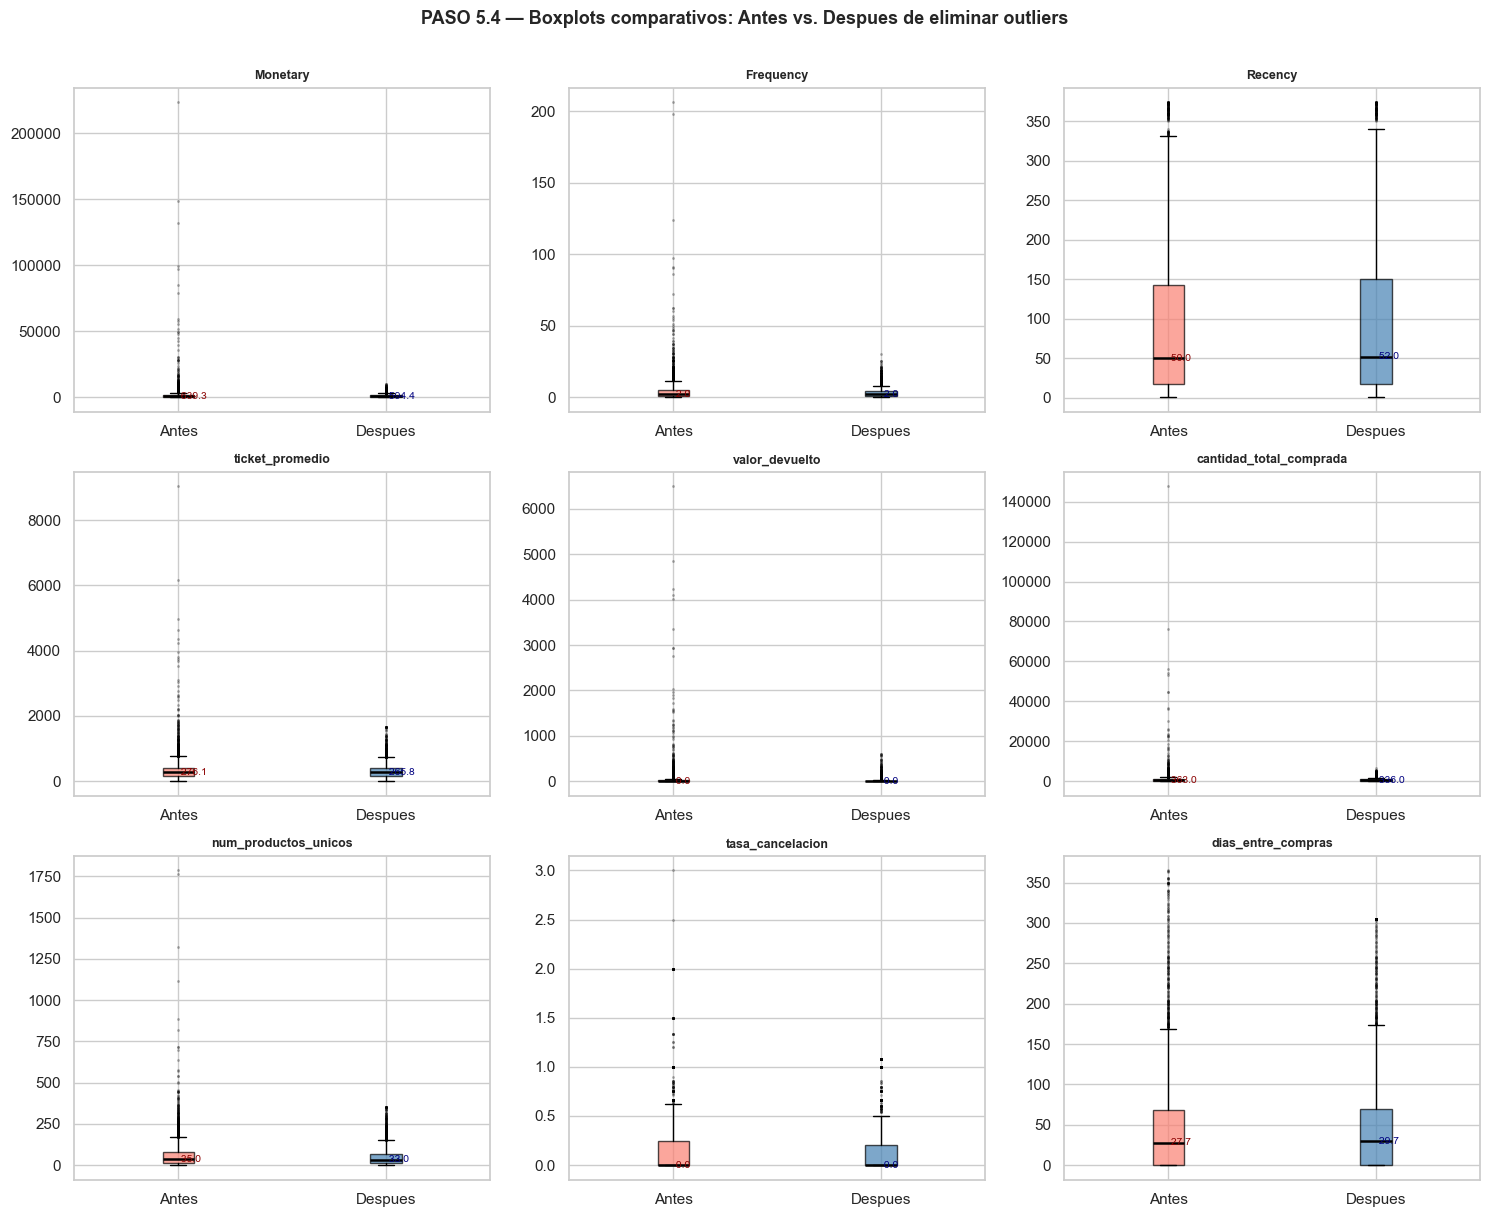

[OK] Grafico guardado en: ../../../graphics/gr_clustering/preprocesing/5.4_boxplots_antes_despues.png

  PASO 5 COMPLETO — Dataset limpio listo para PASO 6 (Scaling)
  Usuarios finales: 4,143  (95.0% del original)


In [110]:
# ── Boxplots comparativos: antes vs. después ──────────────────────────────────
FEATURES_BOX = [
    'Monetary', 'Frequency', 'Recency',
    'ticket_promedio', 'valor_devuelto',
    'cantidad_total_comprada', 'num_productos_unicos',
    'tasa_cancelacion', 'dias_entre_compras',
]

NCOLS_B = 3
NROWS_B = 3

fig, axes = plt.subplots(NROWS_B, NCOLS_B, figsize=(15, NROWS_B * 4))
fig.suptitle('PASO 5.4 — Boxplots comparativos: Antes vs. Despues de eliminar outliers',
             fontsize=13, fontweight='bold', y=1.01)

for idx, col in enumerate(FEATURES_BOX):
    ax = axes[idx // NCOLS_B][idx % NCOLS_B]

    datos_antes   = df_rfm[col].dropna().values
    datos_despues = df_rfm_clean[col].dropna().values

    bp = ax.boxplot(
        [datos_antes, datos_despues],
        labels=['Antes', 'Despues'],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='black', linewidth=1.8),
        flierprops=dict(marker='.', markersize=2, alpha=0.3),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
    )
    bp['boxes'][0].set_facecolor('salmon')
    bp['boxes'][1].set_facecolor('steelblue')

    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('')

    # Anotar mediana de cada grupo
    med_a = df_rfm[col].median()
    med_d = df_rfm_clean[col].median()
    ax.text(1, med_a, f' {med_a:.1f}', va='center', fontsize=7.5, color='darkred')
    ax.text(2, med_d, f' {med_d:.1f}', va='center', fontsize=7.5, color='navy')

plt.tight_layout()
ruta_grafico = RUTA_GRAFICOS + '5.4_boxplots_antes_despues.png'
plt.savefig(ruta_grafico, dpi=110, bbox_inches='tight')
plt.show()
print(f'[OK] Grafico guardado en: {ruta_grafico}')
print()
print('='*80)
print('  PASO 5 COMPLETO — Dataset limpio listo para PASO 6 (Scaling)')
print(f'  Usuarios finales: {len(df_rfm_clean):,}  ({len(df_rfm_clean)/len(df_rfm)*100:.1f}% del original)')
print('='*80)

## PASO 6: Escalado y Normalización

### Decisión: RobustScaler ✓

El clustering se basa en distancias entre puntos, por lo que **todas las features numéricas deben estar en la misma escala**. Elegimos `RobustScaler` por las siguientes razones:

| Método | Fórmula | Problema |
|--------|---------|---------|
| **RobustScaler** ✓ | `(X − mediana) / IQR` | **Ninguno** — robusto frente a outliers residuales |
| StandardScaler | `(X − μ) / σ` | Sensible a outliers (usa media y desviación estándar) |
| MinMaxScaler | `(X − min) / (max − min)` | Muy sensible a extremos (usa min/max) |

> **Nota**: aunque aplicamos Isolation Forest (Paso 5.2), pueden quedar outliers leves. RobustScaler es el más adecuado en este contexto.

### Features afectadas

| Escalar | NO escalar |
|---------|-----------|
| Todas las de `COLS_NUMERICAS` (18 features) | `CustomerID` + `COLS_CATEGORICAS` (`dia_semana_mas_frecuente`, `pais`) |

> Las variables categóricas se codificarán en el **Paso 7 (One-Hot Encoding)** antes de aplicar PCA.

In [115]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 6.1: DECISIÓN — MÉTODO DE ESCALADO
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
import numpy as np

print('='*80)
print('  PASO 6.1: DECISIÓN — MÉTODO DE ESCALADO')
print('='*80)
print()

# ── Tabla comparativa de métodos ──────────────────────────────────────────────
print('Comparativa de métodos de escalado:')
print(f'  {"─"*78}')
print(f'  {"Método":<20} {"Fórmula":<30} {"Sensible outliers":>18} {"Decisión":>12}')
print(f'  {"─"*78}')
print(f'  {"RobustScaler":<20} {"(X - mediana) / IQR":<30} {"NO (usa mediana)":>18} {"ELEGIDO":>12}')
print(f'  {"StandardScaler":<20} {"(X - media) / std":<30} {"SÍ (usa media)"  :>18} {"Descartado":>12}')
print(f'  {"MinMaxScaler":<20} {"(X - min) / (max - min)":<30} {"MUY SENSIBLE"    :>18} {"Descartado":>12}')
print(f'  {"─"*78}')
print()

# ── Demostración empírica con Monetary (feature con mayor skew) ───────────────
print('Demostración empírica sobre "Monetary" (feature con mayor skewness):')
print(f'  {"─"*78}')

col_demo = 'Monetary'
serie = df_rfm_clean[col_demo].values.reshape(-1, 1)

scalers = {
    'RobustScaler (ELEGIDO)': RobustScaler(),
    'StandardScaler'        : StandardScaler(),
    'MinMaxScaler'          : MinMaxScaler(),
}

print(f'  {"Método":<25} {"Media":>8} {"Mediana":>9} {"Std":>8} {"Min":>10} {"Max":>10} {"IQR":>8}')
print(f'  {"─"*78}')

for nombre, sc in scalers.items():
    arr = sc.fit_transform(serie).ravel()
    q1, q3 = np.percentile(arr, 25), np.percentile(arr, 75)
    marker = ' <-- robusto' if 'Robust' in nombre else ''
    print(f'  {nombre:<25} {arr.mean():>8.3f} {np.median(arr):>9.3f} {arr.std():>8.3f} '
          f'{arr.min():>10.3f} {arr.max():>10.3f} {q3-q1:>8.3f}{marker}')

print()

# ── Justificación de la elección ──────────────────────────────────────────────
print('Justificación de la elección:')
print(f'  {"─"*78}')
print('  [1] Isolation Forest eliminó el 5% más anómalo, pero pueden quedar')
print('      outliers leves — RobustScaler es resistente a ellos.')
print('  [2] RobustScaler usa la mediana y el IQR: no se ve afectado por')
print('      valores extremos que aún puedan existir.')
print('  [3] StandardScaler usa la media, que sí se desplaza con outliers.')
print('  [4] MinMaxScaler usa min y max: un solo valor extremo puede')
print('      comprimir toda la distribución hacia cero.')
print()

# ── Features que se escalarán / no se escalarán ───────────────────────────────
print('Features afectadas:')
print(f'  {"─"*78}')
print(f'  Escalar     ({len(COLS_NUMERICAS):>2} features) : {COLS_NUMERICAS}')
print(f'  NO escalar                  : ["CustomerID"] + {COLS_CATEGORICAS}')
print()
print('='*80)
print('  DECISIÓN: RobustScaler — se aplicará en PASO 6.2')
print('='*80)


  PASO 6.1: DECISIÓN — MÉTODO DE ESCALADO

Comparativa de métodos de escalado:
  ──────────────────────────────────────────────────────────────────────────────
  Método               Fórmula                         Sensible outliers     Decisión
  ──────────────────────────────────────────────────────────────────────────────
  RobustScaler         (X - mediana) / IQR              NO (usa mediana)      ELEGIDO
  StandardScaler       (X - media) / std                  SÍ (usa media)   Descartado
  MinMaxScaler         (X - min) / (max - min)              MUY SENSIBLE   Descartado
  ──────────────────────────────────────────────────────────────────────────────

Demostración empírica sobre "Monetary" (feature con mayor skewness):
  ──────────────────────────────────────────────────────────────────────────────
  Método                       Media   Mediana      Std        Min        Max      IQR
  ──────────────────────────────────────────────────────────────────────────────
  RobustScaler 

## PASO 6.2: Aplicación del Escalado

Se aplica `RobustScaler` sobre las **18 features numéricas** de `df_rfm_clean`. El proceso sigue tres subpasos:

| Subpaso | Acción |
|---------|--------|
| **6.2.A** | Separar features a escalar (`COLS_NUMERICAS`) de las que no (`CustomerID`, categóricas) |
| **6.2.B** | `fit_transform` sobre las numéricas → `df_users_scaled` + guardar scaler con `joblib` |
| **6.2.C** | Verificar que **mediana ≈ 0** e **IQR ≈ 1** post-escalado + histogramas comparativos |

> Para `RobustScaler` la referencia correcta es **mediana ≈ 0** e **IQR ≈ 1** (no media/std como en StandardScaler).

In [116]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 6.2.A — SELECCIÓN DE FEATURES
#   PASO 6.2.B — FIT + TRANSFORM + GUARDAR SCALER
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import RobustScaler
import joblib
import os

print('='*80)
print('  PASO 6.2: APLICACIÓN DEL ESCALADO (RobustScaler)')
print('='*80)
print()

# ── 6.2.A: Selección de features ─────────────────────────────────────────────
print('6.2.A — Selección de features a escalar / no escalar:')
print(f'  {"─"*78}')
print(f'  Escalar     ({len(COLS_NUMERICAS):>2} features) :')
for i in range(0, len(COLS_NUMERICAS), 3):
    chunk = COLS_NUMERICAS[i:i+3]
    print(f'     {", ".join(chunk)}')
print()
print(f'  NO escalar  :  CustomerID  |  {COLS_CATEGORICAS}')
print()

# ── 6.2.B: Fit + Transform ───────────────────────────────────────────────────
print('6.2.B — Fit y Transform:')
print(f'  {"─"*78}')

# Extraer solo columnas numéricas como numpy array
X_num_raw = df_rfm_clean[COLS_NUMERICAS].values

# Crear y ajustar el scaler
scaler_robust_final = RobustScaler()
X_num_scaled = scaler_robust_final.fit_transform(X_num_raw)

# Construir DataFrame escalado manteniendo CustomerID y categóricas sin cambio
df_users_scaled = df_rfm_clean[['CustomerID'] + COLS_CATEGORICAS].copy().reset_index(drop=True)
df_scaled_num   = pd.DataFrame(X_num_scaled, columns=COLS_NUMERICAS)
df_users_scaled = pd.concat([df_users_scaled, df_scaled_num], axis=1)

print(f'  [OK] RobustScaler ajustado y transformado')
print(f'       Usuarios      : {df_users_scaled.shape[0]:,}')
print(f'       Columnas total: {df_users_scaled.shape[1]}  '
      f'(1 ID + {len(COLS_CATEGORICAS)} categ. + {len(COLS_NUMERICAS)} num. escaladas)')
print()

# ── Guardar scaler con joblib ─────────────────────────────────────────────────
print('  Guardando scaler...')
os.makedirs(RUTA_MODELS, exist_ok=True)
ruta_scaler_robust = RUTA_MODELS + 'robust_scaler_final.pkl'
joblib.dump(scaler_robust_final, ruta_scaler_robust)
print(f'  [OK] Scaler guardado en: {ruta_scaler_robust}')
print()

# ── Vista previa del dataset escalado ─────────────────────────────────────────
print('  Vista previa df_users_scaled (primeras 3 filas):')
print(f'  {"─"*78}')
cols_preview = ['CustomerID'] + COLS_NUMERICAS[:5]
print(df_users_scaled[cols_preview].head(3).to_string(index=False))
print()
print('='*80)
print('  PASO 6.2.B COMPLETO')
print('='*80)


  PASO 6.2: APLICACIÓN DEL ESCALADO (RobustScaler)

6.2.A — Selección de features a escalar / no escalar:
  ──────────────────────────────────────────────────────────────────────────────
  Escalar     (18 features) :
     Recency, Frequency, Monetary
     num_meses_activo, frecuencia_mensual, dias_entre_compras
     ticket_promedio, gasto_mensual, num_productos_unicos
     diversidad_producto, cantidad_total_comprada, cantidad_promedio_por_compra
     num_cancelaciones, tasa_cancelacion, valor_devuelto
     ratio_devolucion_monetario, compras_fin_semana, ratio_fin_semana

  NO escalar  :  CustomerID  |  ['dia_semana_mas_frecuente', 'pais']

6.2.B — Fit y Transform:
  ──────────────────────────────────────────────────────────────────────────────
  [OK] RobustScaler ajustado y transformado
       Usuarios      : 4,143
       Columnas total: 21  (1 ID + 2 categ. + 18 num. escaladas)

  Guardando scaler...
  [OK] Scaler guardado en: ../../../models/robust_scaler_final.pkl

  Vista previa d

  PASO 6.2.C: VERIFICACIÓN POST-ESCALADO

Estadísticas post-escalado (RobustScaler → mediana ≈ 0, IQR ≈ 1):
  ──────────────────────────────────────────────────────────────────────────────
  Feature                                   Mediana      IQR    Media      Std      Min      Max     OK?
  ──────────────────────────────────────────────────────────────────────────────
  Recency                                     0.000    1.000    0.326    0.764   -0.383    2.421    [OK]
  Frequency                                   0.000    1.000    0.443    1.103   -0.667    9.333    [OK]
  Monetary                                    0.000    1.000    0.430    1.168   -0.541    8.803    [OK]
  num_meses_activo                            0.000    1.000    0.242    0.741   -0.667    3.667    [OK]
  frecuencia_mensual                          0.000    1.000    0.731    1.635   -5.000   10.000    [OK]
  dias_entre_compras                          0.000    1.000    0.261    0.897   -0.426    3.955    

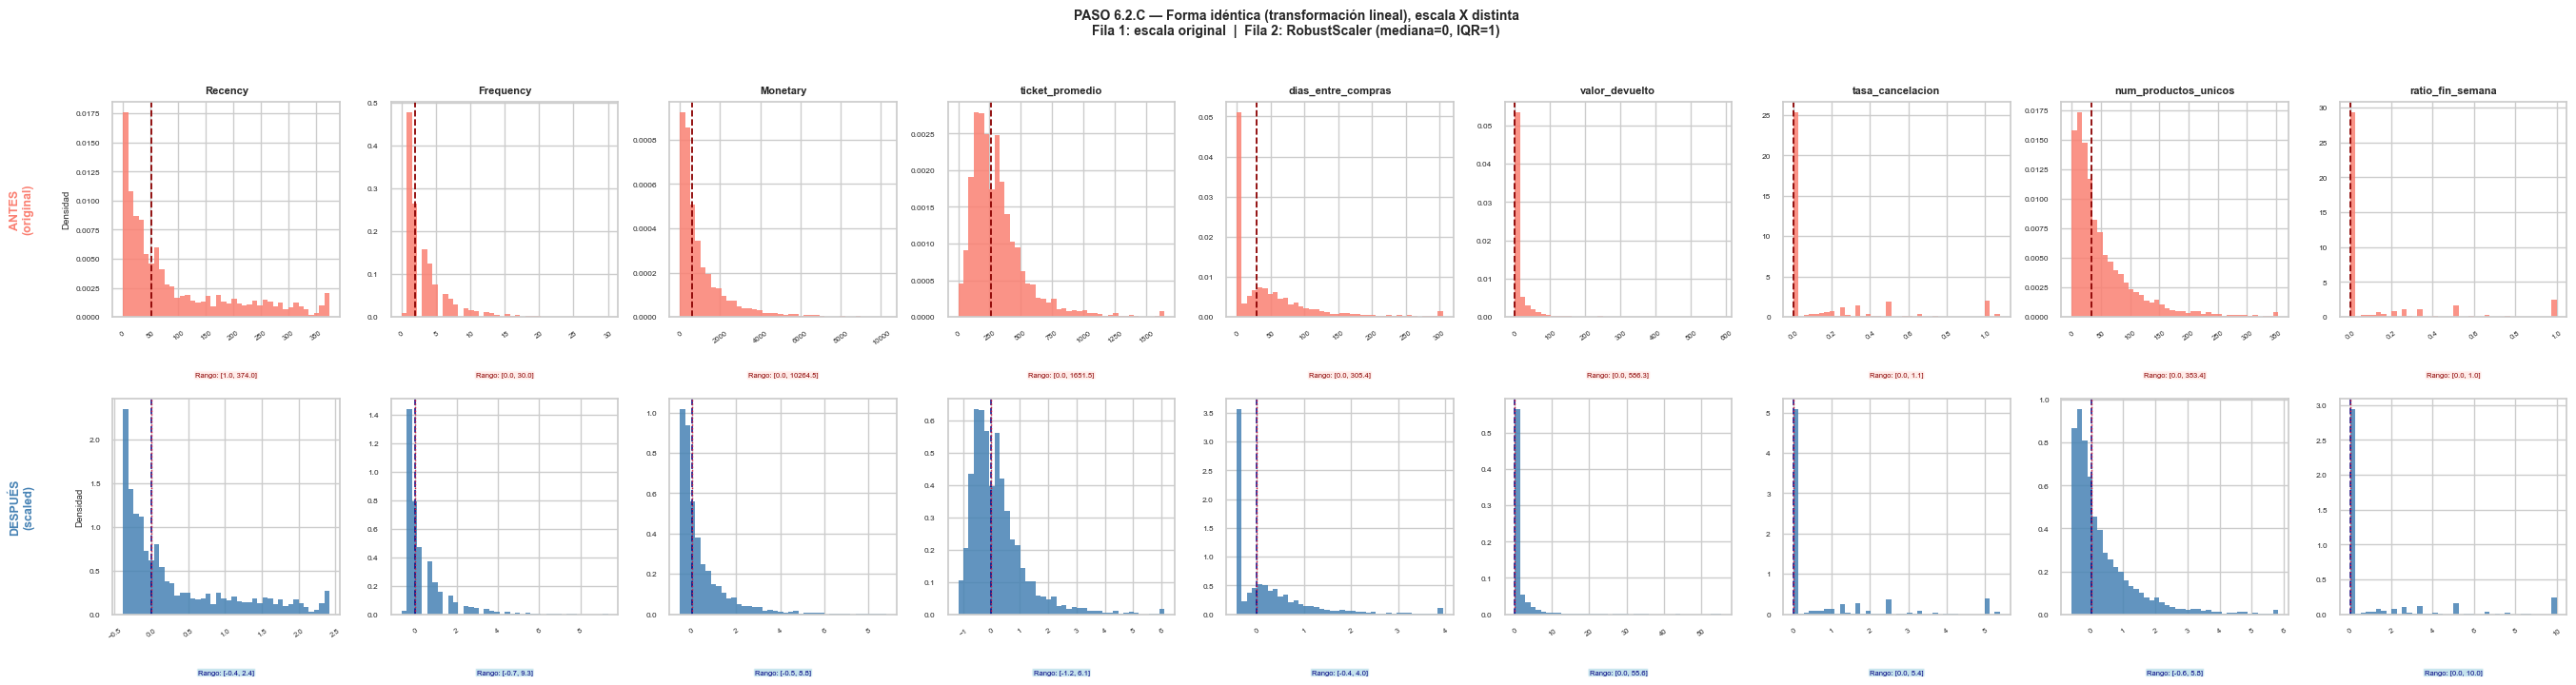

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/6.2_histogramas_antes_despues_scaling.png

  PASO 6.2 COMPLETO — df_users_scaled listo para PASO 7 (Encoding)
  Shape: 4,143 usuarios × 21 columnas


In [119]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 6.2.C — VERIFICACIÓN POST-ESCALADO
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 6.2.C: VERIFICACIÓN POST-ESCALADO')
print('='*80)
print()

# ── Tabla estadísticas post-escalado ─────────────────────────────────────────
# Para RobustScaler: mediana ≈ 0, IQR ≈ 1
print('Estadísticas post-escalado (RobustScaler → mediana ≈ 0, IQR ≈ 1):')
print(f'  {"─"*78}')
print(f'  {"Feature":<40} {"Mediana":>8} {"IQR":>8} {"Media":>8} {"Std":>8} {"Min":>8} {"Max":>8}  {"OK?":>6}')
print(f'  {"─"*78}')

errores_rango = []
for col in COLS_NUMERICAS:
    arr  = df_users_scaled[col].values
    med  = float(np.median(arr))
    q1_v = float(np.percentile(arr, 25))
    q3_v = float(np.percentile(arr, 75))
    iqr  = q3_v - q1_v
    mean = float(arr.mean())
    std  = float(arr.std())
    ok   = abs(med) < 0.05 and abs(iqr - 1.0) < 0.05
    marca = '[OK]' if ok else '[REV]'
    if not ok:
        errores_rango.append(col)
    print(f'  {col:<40} {med:>8.3f} {iqr:>8.3f} {mean:>8.3f} {std:>8.3f} '
          f'{arr.min():>8.3f} {arr.max():>8.3f}  {marca:>6}')

print()
if errores_rango:
    print(f'  [!] Features con mediana o IQR fuera de rango esperado: {errores_rango}')
else:
    print('  [OK] Todas las features tienen mediana ≈ 0 e IQR ≈ 1')
print()

# ── Nota explicativa ──────────────────────────────────────────────────────────
print('  NOTA: RobustScaler es una transformación LINEAL → la FORMA del')
print('  histograma no cambia. Lo que cambia es el EJE X (la escala).')
print('  Antes: unidades originales (£, días, conteos...)')
print('  Después: centrado en 0, con IQR=1 (sin unidades)')
print()

# ── Histogramas: fila superior = ANTES, fila inferior = DESPUÉS ───────────────
# Cada columna tiene su propio eje X. Se añade anotación con rango antes/después.
FEATURES_VIZ_6 = [
    'Recency', 'Frequency', 'Monetary',
    'ticket_promedio', 'dias_entre_compras',
    'valor_devuelto', 'tasa_cancelacion',
    'num_productos_unicos', 'ratio_fin_semana',
]

NCOLS = len(FEATURES_VIZ_6)
fig, axes = plt.subplots(2, NCOLS, figsize=(NCOLS * 3, 7))
fig.suptitle(
    'PASO 6.2.C — Forma idéntica (transformación lineal), escala X distinta\n'
    'Fila 1: escala original  |  Fila 2: RobustScaler (mediana=0, IQR=1)',
    fontsize=10, fontweight='bold', y=1.03
)

for idx, col in enumerate(FEATURES_VIZ_6):
    datos_antes   = df_rfm_clean[col].dropna().values
    datos_despues = df_users_scaled[col].dropna().values

    med_a = float(np.median(datos_antes))
    med_d = float(np.median(datos_despues))
    rango_a = f'[{datos_antes.min():.1f}, {datos_antes.max():.1f}]'
    rango_d = f'[{datos_despues.min():.1f}, {datos_despues.max():.1f}]'

    # ── Fila 0: ANTES ────────────────────────────────────────────────────────
    ax_top = axes[0, idx]
    ax_top.hist(datos_antes, bins=40, color='salmon', edgecolor='none',
                alpha=0.85, density=True)
    ax_top.set_title(col, fontsize=8, fontweight='bold')
    ax_top.set_ylabel('Densidad' if idx == 0 else '', fontsize=7)
    ax_top.tick_params(axis='x', labelsize=5.5, rotation=35)
    ax_top.tick_params(axis='y', labelsize=6)
    ax_top.axvline(med_a, color='darkred', linestyle='--', linewidth=1.3)
    # Anotación: rango original
    ax_top.text(0.5, -0.28, f'Rango: {rango_a}', transform=ax_top.transAxes,
                ha='center', fontsize=5.5, color='darkred',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='mistyrose', alpha=0.7))

    # ── Fila 1: DESPUÉS ──────────────────────────────────────────────────────
    ax_bot = axes[1, idx]
    ax_bot.hist(datos_despues, bins=40, color='steelblue', edgecolor='none',
                alpha=0.85, density=True)
    ax_bot.set_ylabel('Densidad' if idx == 0 else '', fontsize=7)
    ax_bot.tick_params(axis='x', labelsize=5.5, rotation=35)
    ax_bot.tick_params(axis='y', labelsize=6)
    ax_bot.axvline(0,     color='navy',   linestyle='--', linewidth=1.3, alpha=0.8)
    ax_bot.axvline(med_d, color='crimson', linestyle=':',  linewidth=1.0)
    # Anotación: rango escalado
    ax_bot.text(0.5, -0.28, f'Rango: {rango_d}', transform=ax_bot.transAxes,
                ha='center', fontsize=5.5, color='navy',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.7))

# Etiquetas de fila
axes[0, 0].annotate('ANTES\n(original)', xy=(-0.4, 0.5), xycoords='axes fraction',
                    fontsize=9, fontweight='bold', color='salmon',
                    va='center', ha='center', rotation=90)
axes[1, 0].annotate('DESPUÉS\n(scaled)', xy=(-0.4, 0.5), xycoords='axes fraction',
                    fontsize=9, fontweight='bold', color='steelblue',
                    va='center', ha='center', rotation=90)

plt.tight_layout()
ruta_grafico = RUTA_GRAFICOS + '6.2_histogramas_antes_despues_scaling.png'
plt.savefig(ruta_grafico, dpi=110, bbox_inches='tight')
plt.show()
print(f'[OK] Gráfico guardado en: {ruta_grafico}')
print()
print('='*80)
print('  PASO 6.2 COMPLETO — df_users_scaled listo para PASO 7 (Encoding)')
print(f'  Shape: {df_users_scaled.shape[0]:,} usuarios × {df_users_scaled.shape[1]} columnas')
print('='*80)
